# Smart Airport Passenger Assistance Multimodal Chatbot

## Phase 1 — Environment Setup

This notebook builds the prototype in Google Colab. CLIP handles images, Whisper handles speech, MiniLM + FAISS handle text retrieval, and Streamlit provides the interface.


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import os

PROJECT_DIR = Path("/content/drive/MyDrive/MMC_Airport_Assistant")

PROJECT_DIR.mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_DIR)

print("Current project directory:")
print(PROJECT_DIR)

Current project directory:
/content/drive/MyDrive/MMC_Airport_Assistant


## Installing Required Libraries

Install the libraries used by the text, image, speech, evaluation and UI parts of the project.


In [ ]:
%pip install -q \
    transformers \
    sentence-transformers \
    faiss-cpu \
    openai-whisper \
    streamlit \
    jiwer \
    librosa

In [ ]:
import subprocess

result = subprocess.run(
    ["ffmpeg", "-version"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(result.stdout.splitlines()[0])
    print("FFmpeg is available.")
else:
    print("FFmpeg is not available.")

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
FFmpeg is available.


## Environment Verification

Check the main library versions and confirm whether a GPU is available.


In [ ]:
import torch
import torchvision
import transformers
import faiss
import whisper
import streamlit
import librosa
import sklearn
import pandas as pd
import numpy as np
import matplotlib

from sentence_transformers import SentenceTransformer

print("=" * 50)
print("ENVIRONMENT CHECK")
print("=" * 50)

print(f"PyTorch:             {torch.__version__}")
print(f"TorchVision:         {torchvision.__version__}")
print(f"Transformers:        {transformers.__version__}")
print(f"Streamlit:           {streamlit.__version__}")
print(f"Librosa:             {librosa.__version__}")
print(f"Scikit-learn:        {sklearn.__version__}")
print(f"Pandas:              {pd.__version__}")
print(f"NumPy:               {np.__version__}")
print(f"Matplotlib:          {matplotlib.__version__}")

print("-" * 50)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Selected device:     {device.upper()}")

if torch.cuda.is_available():
    print(f"GPU device:          {torch.cuda.get_device_name(0)}")

print("=" * 50)
print("Environment setup completed successfully.")

ENVIRONMENT CHECK
PyTorch:             2.11.0+cu128
TorchVision:         0.26.0+cu128
Transformers:        5.16.1
Streamlit:           1.64.0
Librosa:             0.11.0
Scikit-learn:        1.6.1
Pandas:              2.2.3
NumPy:               2.1.3
Matplotlib:          3.10.0
--------------------------------------------------
Selected device:     CUDA
GPU device:          Tesla T4
Environment setup completed successfully.


In [ ]:
from pathlib import Path

folders = [
    "data",
    "data/images",
    "data/audio",
    "evaluation",
    "screenshots"
]

for folder in folders:
    path = PROJECT_DIR / folder
    path.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


## Project Structure

```text
MMC_Airport_Assistant/
├── data/
│   ├── airport_kb.json
│   ├── text_queries.csv
│   ├── images/
│   └── audio/
├── evaluation/
├── screenshots/
├── text_processor.py
├── image_processor.py
├── audio_processor.py
├── multimodal_assistant.py
├── app.py
└── requirements.txt
```


In [ ]:
%%writefile requirements.txt
torch
torchvision
transformers
sentence-transformers
faiss-cpu
openai-whisper
streamlit
jiwer
librosa
scikit-learn
pandas
numpy
matplotlib
Pillow

Overwriting requirements.txt


In [ ]:
print("PROJECT STRUCTURE")
print("=" * 50)

for path in sorted(PROJECT_DIR.rglob("*")):
    relative_path = path.relative_to(PROJECT_DIR)

    if path.is_dir():
        print(f"📁 {relative_path}/")
    else:
        print(f"📄 {relative_path}")

PROJECT STRUCTURE
📄 Airport_Multimodal_Assistant.ipynb
📁 __pycache__/
📄 __pycache__/app.cpython-313.pyc
📄 __pycache__/audio_processor.cpython-313.pyc
📄 __pycache__/image_processor.cpython-313.pyc
📄 __pycache__/multimodal_assistant.cpython-313.pyc
📄 __pycache__/text_processor.cpython-313.pyc
📄 app.py
📄 audio_processor.py
📁 data/
📄 data/airport_kb.json
📁 data/audio/
📄 data/audio/audio_01_gate.wav
📄 data/audio/audio_02_baggage.wav
📄 data/audio/audio_03_checkin.wav
📄 data/audio/audio_04_security.wav
📄 data/audio/audio_05_lounge.wav
📄 data/audio/audio_06_restaurant.wav
📄 data/audio/audio_07_transport.wav
📄 data/audio/audio_08_information.wav
📄 data/audio/audio_09_lost.wav
📄 data/audio/audio_10_assistance.wav
📄 data/audio_metadata.csv
📄 data/clip_category_index.faiss
📄 data/dataset_summary.json
📄 data/image_labels.csv
📁 data/images/
📁 data/images/baggage_claim/
📄 data/images/baggage_claim/baggage_claim_01.png
📄 data/images/baggage_claim/baggage_claim_02.png
📄 data/images/baggage_claim/baggag

# Phase 2 — Data Acquisition and Exploration

This phase prepares the data used by the prototype: a fictional airport knowledge base, passenger text queries, synthetic airport-sign images and synthetic voice samples. SkyPort International Airport is fictional so the project can be tested without relying on live airport data.


In [ ]:
from pathlib import Path

DATA_DIR = PROJECT_DIR / "data"
IMAGE_DIR = DATA_DIR / "images"
AUDIO_DIR = DATA_DIR / "audio"
SCREENSHOT_DIR = PROJECT_DIR / "screenshots"

DATA_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(exist_ok=True)
AUDIO_DIR.mkdir(exist_ok=True)
SCREENSHOT_DIR.mkdir(exist_ok=True)

print("Data directory:", DATA_DIR)
print("Image directory:", IMAGE_DIR)
print("Audio directory:", AUDIO_DIR)

Data directory: /content/drive/MyDrive/MMC_Airport_Assistant/data
Image directory: /content/drive/MyDrive/MMC_Airport_Assistant/data/images
Audio directory: /content/drive/MyDrive/MMC_Airport_Assistant/data/audio


## 2.1 Airport Knowledge Base

The JSON knowledge base is the main source of airport information. It contains 20 records with fields such as service name, category, terminal, location, opening hours, directions, accessibility and related facilities.


In [ ]:
import json

airport_kb = [
    {
        "record_id": "gate_a05",
        "name": "Gate A05",
        "category": "gate",
        "terminal": "Terminal 1",
        "floor_zone": "Level 2, Zone A",
        "description": "Passenger departure gate located in Zone A.",
        "opening_hours": "According to flight schedule",
        "directions": "From the main security checkpoint, follow signs for Gates A01-A10.",
        "accessibility": "Lift access and wheelchair-accessible route available.",
        "related_facilities": ["Restrooms", "Airport Cafe"],
        "assistance_contact": "Terminal 1 Information Desk"
    },
    {
        "record_id": "gate_a12",
        "name": "Gate A12",
        "category": "gate",
        "terminal": "Terminal 1",
        "floor_zone": "Level 2, Zone A",
        "description": "Passenger departure gate located in the second section of Zone A.",
        "opening_hours": "According to flight schedule",
        "directions": "After security, continue through Zone A and follow signs for Gates A11-A20.",
        "accessibility": "Step-free access and wheelchair assistance available.",
        "related_facilities": ["Restrooms", "Food Court"],
        "assistance_contact": "Terminal 1 Information Desk"
    },
    {
        "record_id": "gate_b12",
        "name": "Gate B12",
        "category": "gate",
        "terminal": "Terminal 1",
        "floor_zone": "Level 2, Zone B",
        "description": "Passenger departure gate situated in Zone B.",
        "opening_hours": "According to flight schedule",
        "directions": "Pass security and follow the blue Zone B signs toward Gates B01-B20.",
        "accessibility": "Lift and wheelchair-accessible route available.",
        "related_facilities": ["Restrooms", "Sky Lounge"],
        "assistance_contact": "Terminal 1 Information Desk"
    },
    {
        "record_id": "gate_c07",
        "name": "Gate C07",
        "category": "gate",
        "terminal": "Terminal 2",
        "floor_zone": "Level 2, Zone C",
        "description": "Passenger departure gate located in Terminal 2 Zone C.",
        "opening_hours": "According to flight schedule",
        "directions": "After Terminal 2 security, follow signs for Gates C01-C10.",
        "accessibility": "Step-free route and mobility assistance available.",
        "related_facilities": ["Restrooms", "Business Lounge"],
        "assistance_contact": "Terminal 2 Information Desk"
    },
    {
        "record_id": "baggage_t1",
        "name": "Baggage Claim Hall A",
        "category": "baggage_claim",
        "terminal": "Terminal 1",
        "floor_zone": "Ground Floor, Arrivals",
        "description": "Main baggage collection area for Terminal 1 arrivals.",
        "opening_hours": "According to arriving flight schedule",
        "directions": "Follow Baggage Claim signs after passport control.",
        "accessibility": "Fully wheelchair accessible.",
        "related_facilities": ["Lost and Found", "Information Desk"],
        "assistance_contact": "Terminal 1 Information Desk"
    },
    {
        "record_id": "baggage_t2",
        "name": "Baggage Claim Hall B",
        "category": "baggage_claim",
        "terminal": "Terminal 2",
        "floor_zone": "Ground Floor, Arrivals",
        "description": "Main baggage collection area for Terminal 2 arrivals.",
        "opening_hours": "According to arriving flight schedule",
        "directions": "After passport control, follow signs for Baggage Claim Hall B.",
        "accessibility": "Step-free access available.",
        "related_facilities": ["Lost and Found", "Information Desk"],
        "assistance_contact": "Terminal 2 Information Desk"
    },
    {
        "record_id": "checkin_t1",
        "name": "Terminal 1 Check-in Area",
        "category": "check_in",
        "terminal": "Terminal 1",
        "floor_zone": "Level 1, Departures",
        "description": "Main airline check-in area for Terminal 1 departures.",
        "opening_hours": "04:00-23:30",
        "directions": "Enter Terminal 1 departures and follow the Check-in signs.",
        "accessibility": "Accessible counters and wheelchair routes available.",
        "related_facilities": ["Information Desk", "Security Control"],
        "assistance_contact": "Terminal 1 Information Desk"
    },
    {
        "record_id": "checkin_t2",
        "name": "Terminal 2 Check-in Area",
        "category": "check_in",
        "terminal": "Terminal 2",
        "floor_zone": "Level 1, Departures",
        "description": "Main airline check-in area for Terminal 2 departures.",
        "opening_hours": "04:00-23:30",
        "directions": "Enter Terminal 2 departures and follow Check-in signs.",
        "accessibility": "Accessible counters and step-free access available.",
        "related_facilities": ["Information Desk", "Security Control"],
        "assistance_contact": "Terminal 2 Information Desk"
    },
    {
        "record_id": "security_t1",
        "name": "Terminal 1 Security Control",
        "category": "security",
        "terminal": "Terminal 1",
        "floor_zone": "Level 1, Departures",
        "description": "Passenger security screening area for Terminal 1.",
        "opening_hours": "04:00-23:30",
        "directions": "Continue past the Terminal 1 check-in desks toward Security.",
        "accessibility": "Assisted security lane available.",
        "related_facilities": ["Check-in Area", "Information Desk"],
        "assistance_contact": "Terminal 1 Information Desk"
    },
    {
        "record_id": "security_t2",
        "name": "Terminal 2 Security Control",
        "category": "security",
        "terminal": "Terminal 2",
        "floor_zone": "Level 1, Departures",
        "description": "Passenger security screening area for Terminal 2.",
        "opening_hours": "04:00-23:30",
        "directions": "Follow Security signs after Terminal 2 check-in.",
        "accessibility": "Assisted security lane available.",
        "related_facilities": ["Check-in Area", "Information Desk"],
        "assistance_contact": "Terminal 2 Information Desk"
    },
    {
        "record_id": "sky_lounge_t1",
        "name": "Sky Lounge",
        "category": "lounge",
        "terminal": "Terminal 1",
        "floor_zone": "Level 2, Zone B",
        "description": "Passenger lounge offering seating, refreshments and Wi-Fi.",
        "opening_hours": "05:00-22:00",
        "directions": "After security, follow signs toward Zone B and take the lift to the lounge level.",
        "accessibility": "Wheelchair accessible.",
        "related_facilities": ["Gate B12", "Restrooms"],
        "assistance_contact": "Sky Lounge Reception"
    },
    {
        "record_id": "business_lounge_t2",
        "name": "Business Lounge",
        "category": "lounge",
        "terminal": "Terminal 2",
        "floor_zone": "Level 2, Zone C",
        "description": "Quiet passenger lounge with seating, refreshments and work areas.",
        "opening_hours": "05:30-22:30",
        "directions": "After Terminal 2 security, follow signs toward Zone C.",
        "accessibility": "Step-free access via lift.",
        "related_facilities": ["Gate C07", "Restrooms"],
        "assistance_contact": "Business Lounge Reception"
    },
    {
        "record_id": "food_court_t1",
        "name": "Terminal 1 Food Court",
        "category": "restaurant",
        "terminal": "Terminal 1",
        "floor_zone": "Level 2, Central Area",
        "description": "Food court offering several quick-service dining options.",
        "opening_hours": "05:00-22:00",
        "directions": "Located after security between Zones A and B.",
        "accessibility": "Wheelchair accessible seating available.",
        "related_facilities": ["Gate A12", "Gate B12"],
        "assistance_contact": "Terminal 1 Information Desk"
    },
    {
        "record_id": "bistro_t2",
        "name": "Airport Bistro",
        "category": "restaurant",
        "terminal": "Terminal 2",
        "floor_zone": "Level 1, Public Area",
        "description": "Restaurant serving meals, snacks and drinks.",
        "opening_hours": "06:00-22:00",
        "directions": "Located near the main Terminal 2 entrance before security.",
        "accessibility": "Wheelchair accessible.",
        "related_facilities": ["Information Desk", "Check-in Area"],
        "assistance_contact": "Terminal 2 Information Desk"
    },
    {
        "record_id": "train_station",
        "name": "Airport Train Station",
        "category": "transport",
        "terminal": "Transport Centre",
        "floor_zone": "Level -1",
        "description": "Rail connection between the airport and the city centre.",
        "opening_hours": "04:30-01:00",
        "directions": "Follow Train Station signs from the arrivals hall and take the escalator or lift to Level -1.",
        "accessibility": "Lift access and step-free platforms available.",
        "related_facilities": ["Ticket Machines", "Information Desk"],
        "assistance_contact": "Transport Information Desk"
    },
    {
        "record_id": "taxi_pickup",
        "name": "Taxi Pickup Zone",
        "category": "transport",
        "terminal": "Ground Transport Area",
        "floor_zone": "Ground Floor, Outside Arrivals",
        "description": "Official airport taxi pickup area.",
        "opening_hours": "24/7",
        "directions": "Exit the arrivals hall and follow Taxi signs to the marked pickup lanes.",
        "accessibility": "Accessible taxis can be requested.",
        "related_facilities": ["Bus Stop", "Information Desk"],
        "assistance_contact": "Transport Information Desk"
    },
    {
        "record_id": "info_t1",
        "name": "Terminal 1 Information Desk",
        "category": "information",
        "terminal": "Terminal 1",
        "floor_zone": "Ground Floor, Central Hall",
        "description": "Passenger information point for airport directions and general assistance.",
        "opening_hours": "05:00-23:00",
        "directions": "Located in the centre of the Terminal 1 public hall.",
        "accessibility": "Lowered accessible service counter available.",
        "related_facilities": ["Check-in Area", "Special Assistance"],
        "assistance_contact": "Airport Customer Service"
    },
    {
        "record_id": "info_t2",
        "name": "Terminal 2 Information Desk",
        "category": "information",
        "terminal": "Terminal 2",
        "floor_zone": "Ground Floor, Central Hall",
        "description": "Passenger information point for Terminal 2.",
        "opening_hours": "05:00-23:00",
        "directions": "Located opposite the Terminal 2 main entrance.",
        "accessibility": "Lowered accessible service counter available.",
        "related_facilities": ["Check-in Area", "Airport Bistro"],
        "assistance_contact": "Airport Customer Service"
    },
    {
        "record_id": "lost_found",
        "name": "Lost and Found Office",
        "category": "lost_and_found",
        "terminal": "Terminal 1",
        "floor_zone": "Ground Floor, Arrivals",
        "description": "Office for reporting and collecting property lost within the airport.",
        "opening_hours": "08:00-20:00",
        "directions": "From Terminal 1 baggage claim, follow Lost and Found signs.",
        "accessibility": "Wheelchair accessible.",
        "related_facilities": ["Baggage Claim Hall A", "Information Desk"],
        "assistance_contact": "Lost and Found Office"
    },
    {
        "record_id": "special_assistance",
        "name": "Special Assistance Desk",
        "category": "special_assistance",
        "terminal": "Terminal 1",
        "floor_zone": "Ground Floor, Main Entrance",
        "description": "Support point for passengers requiring mobility or additional travel assistance.",
        "opening_hours": "04:30-23:30",
        "directions": "Located beside the Terminal 1 Information Desk near the main entrance.",
        "accessibility": "Designed for passengers with reduced mobility and additional support needs.",
        "related_facilities": ["Information Desk", "Check-in Area"],
        "assistance_contact": "Special Assistance Team"
    }
]

kb_path = DATA_DIR / "airport_kb.json"

with open(kb_path, "w", encoding="utf-8") as f:
    json.dump(airport_kb, f, indent=4, ensure_ascii=False)

print(f"Knowledge base saved to: {kb_path}")
print(f"Number of records: {len(airport_kb)}")

Knowledge base saved to: /content/drive/MyDrive/MMC_Airport_Assistant/data/airport_kb.json
Number of records: 20


### Knowledge Base Validation

Check the number of records, unique IDs and required fields before using the knowledge base.


In [ ]:
import pandas as pd

kb_df = pd.DataFrame(airport_kb)

required_fields = [
    "record_id",
    "name",
    "category",
    "terminal",
    "floor_zone",
    "description",
    "opening_hours",
    "directions",
    "accessibility",
    "related_facilities",
    "assistance_contact"
]

assert len(kb_df) == 20
assert kb_df["record_id"].is_unique
assert all(field in kb_df.columns for field in required_fields)
assert kb_df[required_fields].isnull().sum().sum() == 0

print("Knowledge base validation passed.")
print("Records:", len(kb_df))
print("Categories:", kb_df["category"].nunique())

display(
    kb_df[
        ["record_id", "name", "category", "terminal", "floor_zone"]
    ]
)

Knowledge base validation passed.
Records: 20
Categories: 10


,record_id,name,category,terminal,floor_zone
0,gate_a05,Gate A05,gate,Terminal 1,"Level 2, Zone A"
1,gate_a12,Gate A12,gate,Terminal 1,"Level 2, Zone A"
2,gate_b12,Gate B12,gate,Terminal 1,"Level 2, Zone B"
3,gate_c07,Gate C07,gate,Terminal 2,"Level 2, Zone C"
4,baggage_t1,Baggage Claim Hall A,baggage_claim,Terminal 1,"Ground Floor, Arrivals"
5,baggage_t2,Baggage Claim Hall B,baggage_claim,Terminal 2,"Ground Floor, Arrivals"
6,checkin_t1,Terminal 1 Check-in Area,check_in,Terminal 1,"Level 1, Departures"
7,checkin_t2,Terminal 2 Check-in Area,check_in,Terminal 2,"Level 1, Departures"
8,security_t1,Terminal 1 Security Control,security,Terminal 1,"Level 1, Departures"
9,security_t2,Terminal 2 Security Control,security,Terminal 2,"Level 1, Departures"


## 2.2 Passenger Text Dataset

The text dataset contains labelled passenger queries with intent, entity, expected KB record and a development/evaluation split. The evaluation rows are kept separate until final testing.


In [ ]:
queries = [
    # GATE
    ("Where is Gate B12?", "gate", "B12", "gate_b12", "evaluation"),
    ("How do I get to Gate A05?", "gate", "A05", "gate_a05", "development"),
    ("Which way is Gate A12?", "gate", "A12", "gate_a12", "development"),
    ("I need to find Gate C07.", "gate", "C07", "gate_c07", "evaluation"),
    ("Can you direct me to Gate B12?", "gate", "B12", "gate_b12", "development"),

    # BAGGAGE
    ("Where is baggage claim in Terminal 1?", "baggage_claim", "Terminal 1", "baggage_t1", "evaluation"),
    ("Where can I collect my luggage in Terminal 2?", "baggage_claim", "Terminal 2", "baggage_t2", "evaluation"),
    ("I need the Terminal 1 baggage hall.", "baggage_claim", "Terminal 1", "baggage_t1", "development"),
    ("Where do I pick up my suitcase in Terminal 2?", "baggage_claim", "Terminal 2", "baggage_t2", "development"),
    ("Which way is baggage collection in Terminal 1?", "baggage_claim", "Terminal 1", "baggage_t1", "development"),

    # CHECK-IN
    ("Where is check-in in Terminal 1?", "check_in", "Terminal 1", "checkin_t1", "evaluation"),
    ("How do I reach the Terminal 2 check-in desks?", "check_in", "Terminal 2", "checkin_t2", "evaluation"),
    ("I need to check in at Terminal 1.", "check_in", "Terminal 1", "checkin_t1", "development"),
    ("Where are the check-in counters in Terminal 2?", "check_in", "Terminal 2", "checkin_t2", "development"),
    ("Can you direct me to Terminal 1 check-in?", "check_in", "Terminal 1", "checkin_t1", "development"),

    # SECURITY
    ("Where is security in Terminal 1?", "security", "Terminal 1", "security_t1", "evaluation"),
    ("How can I reach Terminal 2 security?", "security", "Terminal 2", "security_t2", "evaluation"),
    ("Where is the security checkpoint in Terminal 1?", "security", "Terminal 1", "security_t1", "development"),
    ("I need the security control in Terminal 2.", "security", "Terminal 2", "security_t2", "development"),
    ("Which way is security in Terminal 1?", "security", "Terminal 1", "security_t1", "development"),

    # LOUNGE
    ("Where is the Sky Lounge?", "lounge", "Sky Lounge", "sky_lounge_t1", "evaluation"),
    ("Is there a lounge in Terminal 2?", "lounge", "Terminal 2", "business_lounge_t2", "evaluation"),
    ("How do I get to the Sky Lounge?", "lounge", "Sky Lounge", "sky_lounge_t1", "development"),
    ("Where is the Business Lounge?", "lounge", "Business Lounge", "business_lounge_t2", "development"),
    ("I need a lounge near Gate B12.", "lounge", "Gate B12", "sky_lounge_t1", "development"),

    # RESTAURANT
    ("Where can I eat in Terminal 1?", "restaurant", "Terminal 1", "food_court_t1", "evaluation"),
    ("Where is the Airport Bistro?", "restaurant", "Airport Bistro", "bistro_t2", "evaluation"),
    ("Is there a food court after security?", "restaurant", "Food Court", "food_court_t1", "development"),
    ("I want a restaurant in Terminal 2.", "restaurant", "Terminal 2", "bistro_t2", "development"),
    ("Where can I get food near Gate B12?", "restaurant", "Gate B12", "food_court_t1", "development"),

    # TRANSPORT
    ("How do I get to the airport train station?", "transport", "Train Station", "train_station", "evaluation"),
    ("Where can I get a taxi?", "transport", "Taxi", "taxi_pickup", "evaluation"),
    ("Which way is the train to the city?", "transport", "Train", "train_station", "development"),
    ("Where is the taxi pickup area?", "transport", "Taxi", "taxi_pickup", "development"),
    ("How can I reach the railway station?", "transport", "Train Station", "train_station", "development"),

    # INFORMATION
    ("Where is the information desk in Terminal 1?", "information", "Terminal 1", "info_t1", "evaluation"),
    ("Is there an information desk in Terminal 2?", "information", "Terminal 2", "info_t2", "evaluation"),
    ("I need passenger information in Terminal 1.", "information", "Terminal 1", "info_t1", "development"),
    ("Where can I ask for help in Terminal 2?", "information", "Terminal 2", "info_t2", "development"),
    ("Show me the Terminal 1 information desk.", "information", "Terminal 1", "info_t1", "development"),

    # LOST AND FOUND
    ("Where is lost and found?", "lost_and_found", "Lost and Found", "lost_found", "evaluation"),
    ("I lost my bag. Where should I go?", "lost_and_found", "Lost property", "lost_found", "evaluation"),
    ("Where can I report a lost item?", "lost_and_found", "Lost item", "lost_found", "development"),
    ("I left my phone at the airport.", "lost_and_found", "Lost property", "lost_found", "development"),
    ("How do I collect something I lost?", "lost_and_found", "Lost property", "lost_found", "development"),

    # SPECIAL ASSISTANCE
    ("Where is the special assistance desk?", "special_assistance", "Special Assistance", "special_assistance", "evaluation"),
    ("I need wheelchair assistance.", "special_assistance", "Wheelchair", "special_assistance", "evaluation"),
    ("Where can a passenger with reduced mobility get help?", "special_assistance", "Reduced mobility", "special_assistance", "development"),
    ("I need mobility support at the airport.", "special_assistance", "Mobility support", "special_assistance", "development"),
    ("Where can I request passenger assistance?", "special_assistance", "Passenger assistance", "special_assistance", "development"),
]

text_df = pd.DataFrame(
    queries,
    columns=[
        "query",
        "intent",
        "entity",
        "expected_record",
        "split"
    ]
)

text_path = DATA_DIR / "text_queries.csv"
text_df.to_csv(text_path, index=False)

print("Text dataset saved to:", text_path)
print("Total queries:", len(text_df))
print()
print(text_df["split"].value_counts())

display(text_df.head(10))

Text dataset saved to: /content/drive/MyDrive/MMC_Airport_Assistant/data/text_queries.csv
Total queries: 50

split
development    30
evaluation     20
Name: count, dtype: int64


,query,intent,entity,expected_record,split
0,Where is Gate B12?,gate,B12,gate_b12,evaluation
1,How do I get to Gate A05?,gate,A05,gate_a05,development
2,Which way is Gate A12?,gate,A12,gate_a12,development
3,I need to find Gate C07.,gate,C07,gate_c07,evaluation
4,Can you direct me to Gate B12?,gate,B12,gate_b12,development
5,Where is baggage claim in Terminal 1?,baggage_claim,Terminal 1,baggage_t1,evaluation
6,Where can I collect my luggage in Terminal 2?,baggage_claim,Terminal 2,baggage_t2,evaluation
7,I need the Terminal 1 baggage hall.,baggage_claim,Terminal 1,baggage_t1,development
8,Where do I pick up my suitcase in Terminal 2?,baggage_claim,Terminal 2,baggage_t2,development
9,Which way is baggage collection in Terminal 1?,baggage_claim,Terminal 1,baggage_t1,development


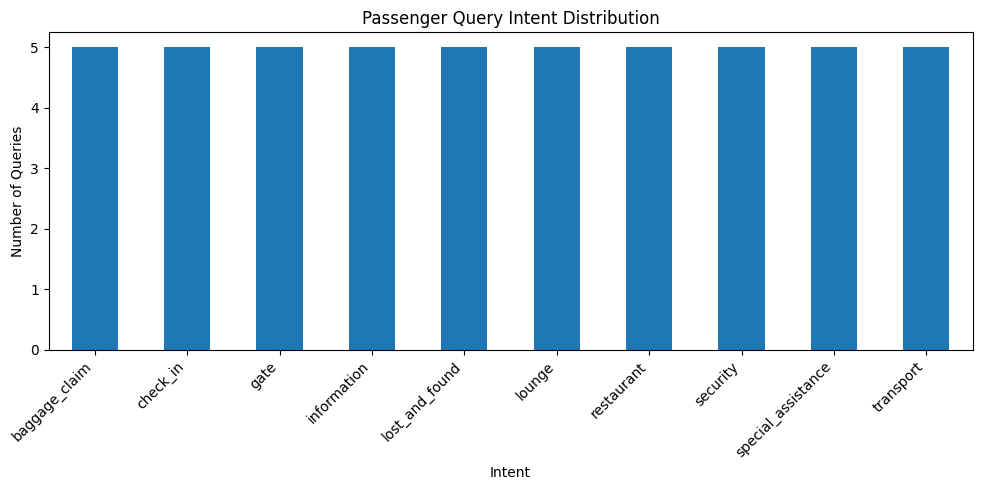

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/screenshots/text_intent_distribution.png


In [ ]:
import matplotlib.pyplot as plt

intent_counts = text_df["intent"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
intent_counts.plot(kind="bar")

plt.title("Passenger Query Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Number of Queries")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

intent_plot_path = SCREENSHOT_DIR / "text_intent_distribution.png"
plt.savefig(intent_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", intent_plot_path)

### Text Vocabulary Exploration

A simple word-frequency check is used to see the most common airport-related terms in the query set.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

vectorizer = CountVectorizer(stop_words="english")

query_matrix = vectorizer.fit_transform(text_df["query"])

word_counts = np.asarray(
    query_matrix.sum(axis=0)
).flatten()

vocabulary_df = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": word_counts
}).sort_values("count", ascending=False)

display(vocabulary_df.head(15))

,word,count
55,terminal,23
37,need,8
26,gate,7
48,security,6
33,lounge,5
12,check,5
58,way,4
32,lost,4
21,desk,4
29,information,4


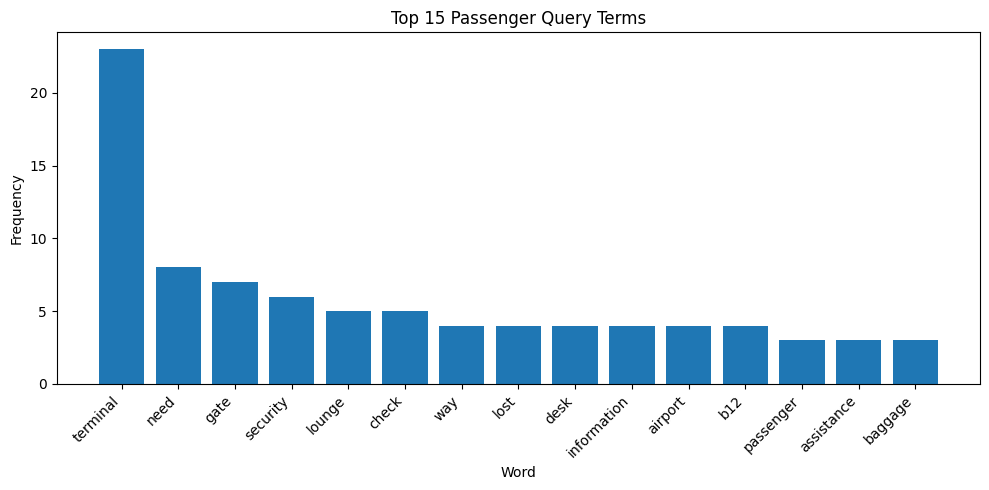

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/screenshots/text_vocabulary_top15.png


In [ ]:
top_words = vocabulary_df.head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_words["word"], top_words["count"])

plt.title("Top 15 Passenger Query Terms")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

vocab_plot_path = SCREENSHOT_DIR / "text_vocabulary_top15.png"
plt.savefig(vocab_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", vocab_plot_path)

In [ ]:
sample_query = text_df.iloc[0]["query"]

sample_tokens = (
    sample_query
    .lower()
    .replace("?", "")
    .split()
)

print("Original query:")
print(sample_query)

print("\nTokenised query:")
print(sample_tokens)

Original query:
Where is Gate B12?

Tokenised query:
['where', 'is', 'gate', 'b12']


## 2.3 Synthetic Airport Sign Dataset

The image dataset contains ten airport-service categories with small changes in wording, brightness and rotation. It is useful for a controlled prototype, but it is less varied than real airport photos.


In [ ]:
image_categories = [
    "gate",
    "baggage_claim",
    "check_in",
    "security",
    "lounge",
    "restaurant",
    "transport",
    "information",
    "lost_and_found",
    "special_assistance"
]

for category in image_categories:
    (IMAGE_DIR / category).mkdir(parents=True, exist_ok=True)

print("Image category folders created:")
for category in image_categories:
    print("-", category)

Image category folders created:
- gate
- baggage_claim
- check_in
- security
- lounge
- restaurant
- transport
- information
- lost_and_found
- special_assistance


In [ ]:
from PIL import Image, ImageDraw, ImageFont, ImageEnhance
import random
from matplotlib import font_manager

random.seed(42)

sign_texts = {
    "gate": [
        "GATE A05",
        "GATE A12",
        "GATE B12",
        "GATE C07",
        "DEPARTURE GATES",
        "GATES A01-A20"
    ],
    "baggage_claim": [
        "BAGGAGE CLAIM",
        "BAGGAGE CLAIM A",
        "BAGGAGE CLAIM B",
        "LUGGAGE COLLECTION",
        "BAGGAGE HALL",
        "CLAIM YOUR BAG"
    ],
    "check_in": [
        "CHECK-IN",
        "CHECK-IN T1",
        "CHECK-IN T2",
        "AIRLINE CHECK-IN",
        "CHECK-IN DESKS",
        "DEPARTURE CHECK-IN"
    ],
    "security": [
        "SECURITY",
        "SECURITY CONTROL",
        "SECURITY T1",
        "SECURITY T2",
        "PASSENGER SECURITY",
        "SECURITY CHECK"
    ],
    "lounge": [
        "AIRPORT LOUNGE",
        "SKY LOUNGE",
        "BUSINESS LOUNGE",
        "LOUNGE",
        "PASSENGER LOUNGE",
        "PREMIUM LOUNGE"
    ],
    "restaurant": [
        "FOOD COURT",
        "RESTAURANT",
        "AIRPORT BISTRO",
        "FOOD & DRINK",
        "CAFE & FOOD",
        "DINING AREA"
    ],
    "transport": [
        "TRAIN STATION",
        "TAXI",
        "AIRPORT TRAIN",
        "GROUND TRANSPORT",
        "TAXI PICKUP",
        "TRANSPORT"
    ],
    "information": [
        "INFORMATION",
        "INFORMATION DESK",
        "PASSENGER INFO",
        "AIRPORT INFORMATION",
        "HELP DESK",
        "INFO"
    ],
    "lost_and_found": [
        "LOST & FOUND",
        "LOST PROPERTY",
        "LOST ITEMS",
        "PROPERTY OFFICE",
        "LOST BAG",
        "LOST AND FOUND"
    ],
    "special_assistance": [
        "SPECIAL ASSISTANCE",
        "ACCESSIBILITY",
        "PASSENGER ASSISTANCE",
        "MOBILITY SUPPORT",
        "ASSISTANCE DESK",
        "ACCESSIBLE SERVICES"
    ]
}

# Find DejaVu Sans Bold automatically
font_path = font_manager.findfont(
    font_manager.FontProperties(
        family="DejaVu Sans",
        weight="bold"
    )
)

print("Font found at:", font_path)

main_font = ImageFont.truetype(font_path, 44)
arrow_font = ImageFont.truetype(font_path, 54)

backgrounds = [
    (16, 43, 73),
    (20, 60, 90),
    (40, 40, 40),
    (25, 75, 65),
    (60, 50, 75)
]

image_records = []

for category, texts in sign_texts.items():

    for index, text in enumerate(texts):

        background = random.choice(backgrounds)

        img = Image.new(
            "RGB",
            (512, 320),
            color=background
        )

        draw = ImageDraw.Draw(img)

        # Airport-style border
        draw.rectangle(
            [12, 12, 500, 308],
            outline=(240, 240, 240),
            width=5
        )

        # Split long signs into two lines
        display_text = text

        if len(text) > 16 and " " in text:
            words = text.split()
            middle = len(words) // 2

            display_text = (
                " ".join(words[:middle])
                + "\n"
                + " ".join(words[middle:])
            )

        draw.multiline_text(
            (256, 135),
            display_text,
            font=main_font,
            fill=(255, 255, 255),
            anchor="mm",
            align="center",
            spacing=8
        )

        arrow = random.choice(["→", "←", "↑"])

        draw.text(
            (256, 245),
            arrow,
            font=arrow_font,
            fill=(255, 215, 0),
            anchor="mm"
        )

        # Small visual variation
        angle = random.choice([-5, -3, 0, 3, 5])

        img = img.rotate(
            angle,
            resample=Image.Resampling.BICUBIC,
            fillcolor=background
        )

        brightness = random.uniform(0.80, 1.20)

        img = ImageEnhance.Brightness(
            img
        ).enhance(brightness)

        split = (
            "development"
            if index < 4
            else "evaluation"
        )

        filename = (
            f"{category}_{index + 1:02d}.png"
        )

        filepath = IMAGE_DIR / category / filename

        img.save(filepath)

        image_records.append({
            "filename": filename,
            "filepath": str(filepath),
            "category": category,
            "display_text": text,
            "split": split
        })

image_df = pd.DataFrame(image_records)

image_labels_path = DATA_DIR / "image_labels.csv"

image_df.to_csv(
    image_labels_path,
    index=False
)

print("Synthetic images created:", len(image_df))
print("Metadata saved to:", image_labels_path)

Font found at: /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf
Synthetic images created: 60
Metadata saved to: /content/drive/MyDrive/MMC_Airport_Assistant/data/image_labels.csv


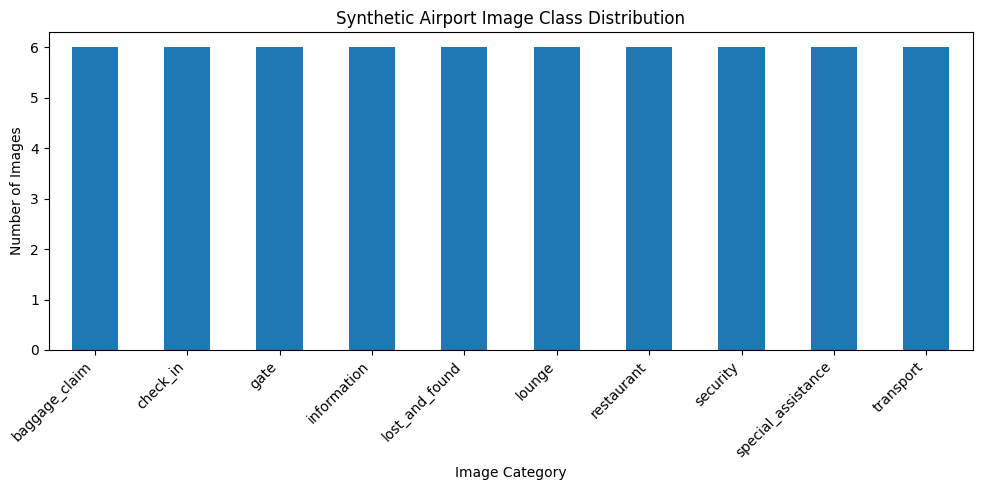

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/screenshots/image_class_distribution.png


In [ ]:
image_counts = (
    image_df["category"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
image_counts.plot(kind="bar")

plt.title("Synthetic Airport Image Class Distribution")
plt.xlabel("Image Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

image_distribution_path = (
    SCREENSHOT_DIR /
    "image_class_distribution.png"
)

plt.savefig(
    image_distribution_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", image_distribution_path)

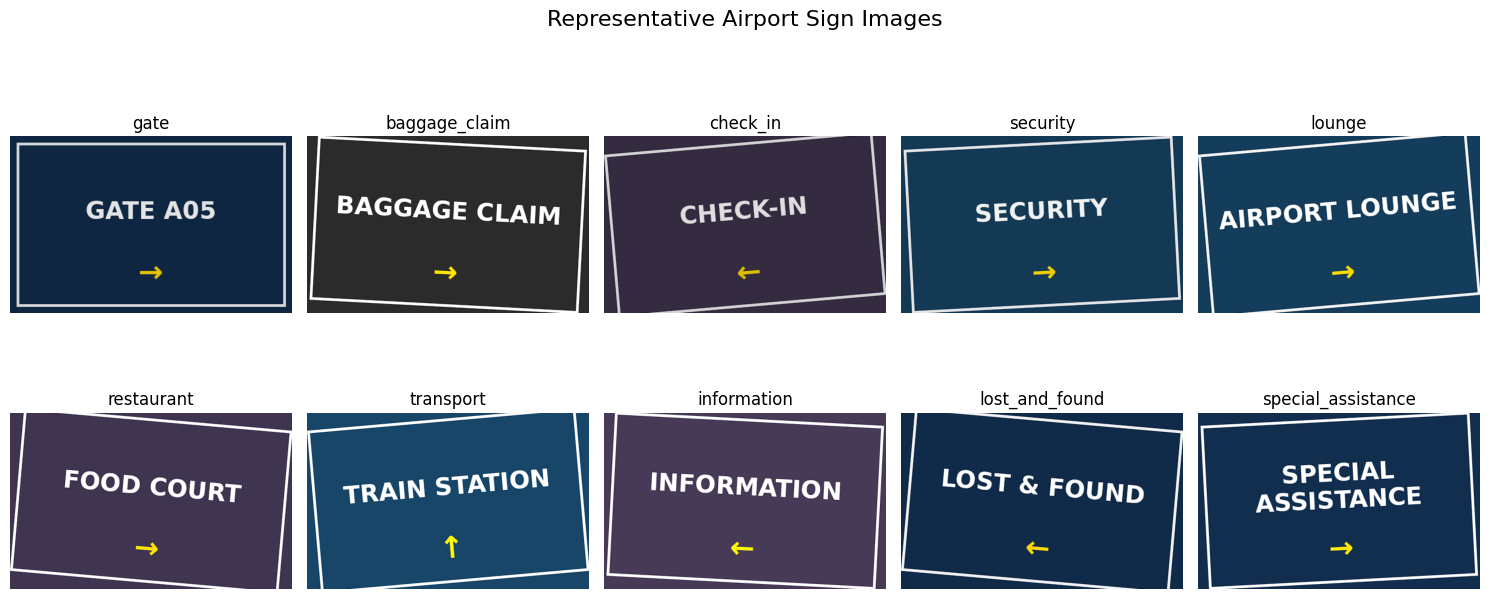

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/screenshots/representative_image_samples.png


In [ ]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)

axes = axes.flatten()

for ax, category in zip(
    axes,
    image_categories
):
    sample_row = (
        image_df[
            image_df["category"] == category
        ]
        .iloc[0]
    )

    image = Image.open(
        sample_row["filepath"]
    )

    ax.imshow(image)
    ax.set_title(category)
    ax.axis("off")

plt.suptitle(
    "Representative Airport Sign Images",
    fontsize=16
)

plt.tight_layout()

sample_path = (
    SCREENSHOT_DIR /
    "representative_image_samples.png"
)

plt.savefig(
    sample_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", sample_path)

### Similar and Dissimilar Visual Examples

Examples from the same class share similar sign content, while different classes represent different airport services. CLIP similarity is tested later in the vision phase.


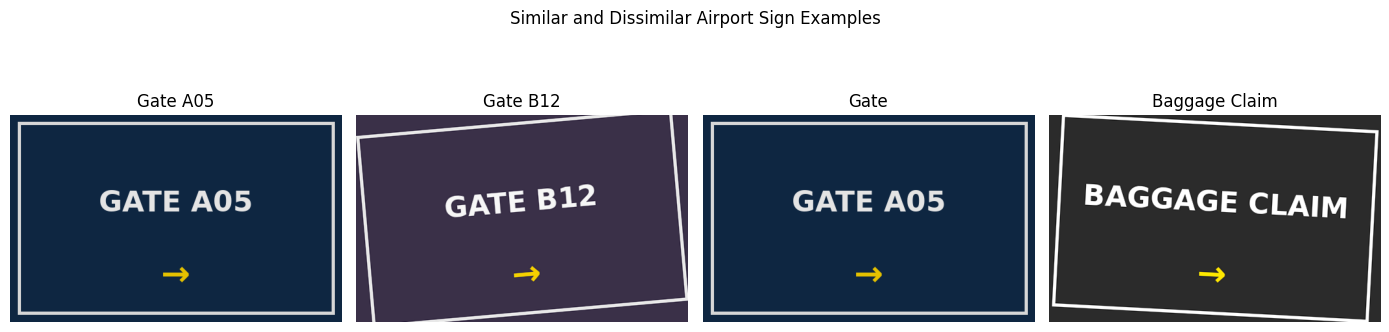

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/screenshots/similar_dissimilar_examples.png


In [ ]:
similar_paths = [
    IMAGE_DIR / "gate" / "gate_01.png",
    IMAGE_DIR / "gate" / "gate_03.png"
]

dissimilar_paths = [
    IMAGE_DIR / "gate" / "gate_01.png",
    IMAGE_DIR / "baggage_claim" / "baggage_claim_01.png"
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

examples = [
    (similar_paths[0], "Gate A05"),
    (similar_paths[1], "Gate B12"),
    (dissimilar_paths[0], "Gate"),
    (dissimilar_paths[1], "Baggage Claim")
]

for ax, (path, title) in zip(axes, examples):
    ax.imshow(Image.open(path))
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(
    "Similar and Dissimilar Airport Sign Examples"
)

plt.tight_layout()

comparison_path = (
    SCREENSHOT_DIR /
    "similar_dissimilar_examples.png"
)

plt.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", comparison_path)

## 2.4 Synthetic Voice Dataset

A small text-to-speech dataset is used to test Whisper in a repeatable way. Real accents and airport noise are not fully represented.


In [ ]:
audio_samples = [
    (
        "audio_01_gate.wav",
        "Where is gate B twelve?",
        "gate",
        "gate_b12"
    ),
    (
        "audio_02_baggage.wav",
        "Where is baggage claim in terminal one?",
        "baggage_claim",
        "baggage_t1"
    ),
    (
        "audio_03_checkin.wav",
        "Where is check in at terminal two?",
        "check_in",
        "checkin_t2"
    ),
    (
        "audio_04_security.wav",
        "How do I reach security in terminal one?",
        "security",
        "security_t1"
    ),
    (
        "audio_05_lounge.wav",
        "Where is the Sky Lounge?",
        "lounge",
        "sky_lounge_t1"
    ),
    (
        "audio_06_restaurant.wav",
        "Where can I get food in terminal one?",
        "restaurant",
        "food_court_t1"
    ),
    (
        "audio_07_transport.wav",
        "How do I get to the train station?",
        "transport",
        "train_station"
    ),
    (
        "audio_08_information.wav",
        "Where is the information desk in terminal two?",
        "information",
        "info_t2"
    ),
    (
        "audio_09_lost.wav",
        "Where can I report a lost bag?",
        "lost_and_found",
        "lost_found"
    ),
    (
        "audio_10_assistance.wav",
        "I need wheelchair assistance.",
        "special_assistance",
        "special_assistance"
    )
]

In [ ]:
import shutil

if shutil.which("espeak-ng") is None:
    print("Installing espeak-ng...")
    !apt-get -qq update
    !apt-get -qq install -y espeak-ng
else:
    print("espeak-ng is already available.")

espeak-ng is already available.


In [ ]:
import subprocess

audio_records = []

for (
    filename,
    reference_text,
    intent,
    expected_record
) in audio_samples:

    filepath = AUDIO_DIR / filename

    subprocess.run(
        [
            "espeak-ng",
            "-s",
            "145",
            "-w",
            str(filepath),
            reference_text
        ],
        check=True
    )

    audio_records.append({
        "filename": filename,
        "filepath": str(filepath),
        "reference_text": reference_text,
        "intent": intent,
        "expected_record": expected_record
    })

audio_df = pd.DataFrame(audio_records)

audio_metadata_path = (
    DATA_DIR /
    "audio_metadata.csv"
)

audio_df.to_csv(
    audio_metadata_path,
    index=False
)

print(
    "Audio samples created:",
    len(audio_df)
)

display(audio_df)

Audio samples created: 10


,filename,filepath,reference_text,intent,expected_record
0,audio_01_gate.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is gate B twelve?,gate,gate_b12
1,audio_02_baggage.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is baggage claim in terminal one?,baggage_claim,baggage_t1
2,audio_03_checkin.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is check in at terminal two?,check_in,checkin_t2
3,audio_04_security.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,How do I reach security in terminal one?,security,security_t1
4,audio_05_lounge.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is the Sky Lounge?,lounge,sky_lounge_t1
5,audio_06_restaurant.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where can I get food in terminal one?,restaurant,food_court_t1
6,audio_07_transport.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,How do I get to the train station?,transport,train_station
7,audio_08_information.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is the information desk in terminal two?,information,info_t2
8,audio_09_lost.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where can I report a lost bag?,lost_and_found,lost_found
9,audio_10_assistance.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,I need wheelchair assistance.,special_assistance,special_assistance


In [ ]:
from IPython.display import Audio, display

sample_audio = AUDIO_DIR / "audio_01_gate.wav"

print(
    "Reference text:",
    audio_df.iloc[0]["reference_text"]
)

display(
    Audio(
        filename=str(sample_audio)
    )
)

Reference text: Where is gate B twelve?


In [ ]:
dataset_summary = {
    "airport": "SkyPort International Airport",
    "airport_type": "Fictional proof-of-concept airport",
    "knowledge_base_records": len(kb_df),
    "knowledge_base_categories": kb_df["category"].nunique(),
    "text_queries": len(text_df),
    "text_development_queries": int(
        (text_df["split"] == "development").sum()
    ),
    "text_evaluation_queries": int(
        (text_df["split"] == "evaluation").sum()
    ),
    "image_samples": len(image_df),
    "image_categories": image_df["category"].nunique(),
    "audio_samples": len(audio_df)
}

summary_path = DATA_DIR / "dataset_summary.json"

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        dataset_summary,
        f,
        indent=4
    )

print(
    json.dumps(
        dataset_summary,
        indent=4
    )
)

{
    "airport": "SkyPort International Airport",
    "airport_type": "Fictional proof-of-concept airport",
    "knowledge_base_records": 20,
    "knowledge_base_categories": 10,
    "text_queries": 50,
    "text_development_queries": 30,
    "text_evaluation_queries": 20,
    "image_samples": 60,
    "image_categories": 10,
    "audio_samples": 10
}


In [ ]:
assert len(kb_df) == 20
assert kb_df["record_id"].is_unique

assert len(text_df) == 50
assert text_df["intent"].nunique() == 10
assert (text_df["split"] == "evaluation").sum() == 20

assert len(image_df) == 60
assert image_df["category"].nunique() == 10

assert len(audio_df) == 10

assert kb_path.exists()
assert text_path.exists()
assert image_labels_path.exists()
assert audio_metadata_path.exists()

print("=" * 55)
print("PHASE 2 DATA INTEGRITY CHECK")
print("=" * 55)

print(f"Knowledge Base : {len(kb_df)} records")
print(f"Text Dataset   : {len(text_df)} queries")
print(f"Image Dataset  : {len(image_df)} images")
print(f"Audio Dataset  : {len(audio_df)} audio samples")

print("-" * 55)

print(
    "KB categories   :",
    kb_df["category"].nunique()
)

print(
    "Text intents    :",
    text_df["intent"].nunique()
)

print(
    "Image categories:",
    image_df["category"].nunique()
)

print("=" * 55)
print("Phase 2 data validation completed successfully.")

PHASE 2 DATA INTEGRITY CHECK
Knowledge Base : 20 records
Text Dataset   : 50 queries
Image Dataset  : 60 images
Audio Dataset  : 10 audio samples
-------------------------------------------------------
KB categories   : 10
Text intents    : 10
Image categories: 10
Phase 2 data validation completed successfully.


## Dataset Limitations

- The airport and KB are fictional and static.
- Images are synthetic and cleaner than real airport photos.
- Image classes are balanced, unlike many real datasets.
- Voice samples are synthetic and contain limited accent/noise variation.
- The text set is small and cannot cover every passenger phrasing.

These limits are considered again in the evaluation and report.


# Phase 3 — Text Understanding and Knowledge-Base Retrieval

Text queries are cleaned, assigned a simple rule-based intent, checked for entities, embedded with `all-MiniLM-L6-v2`, and matched to the airport KB with FAISS. No fine-tuning is used.


## 3.1 Loading Text and Knowledge-Base Data

Load the KB and labelled passenger-query dataset created in Phase 2.


In [ ]:
import json
import pandas as pd

kb_path = DATA_DIR / "airport_kb.json"
text_path = DATA_DIR / "text_queries.csv"

with open(kb_path, "r", encoding="utf-8") as f:
    airport_kb = json.load(f)

text_df = pd.read_csv(text_path)

print("Knowledge-base records:", len(airport_kb))
print("Passenger queries:", len(text_df))
print("Development queries:", (text_df["split"] == "development").sum())
print("Evaluation queries:", (text_df["split"] == "evaluation").sum())

Knowledge-base records: 20
Passenger queries: 50
Development queries: 30
Evaluation queries: 20


## 3.2 Text Preprocessing

Queries are lowercased, punctuation is removed and whitespace is normalised while keeping identifiers such as `B12` and `Terminal 2`. Stop words are kept because MiniLM uses the full sentence context.


In [ ]:
import re

def preprocess_query(text):
    """
    Perform lightweight preprocessing while preserving
    airport identifiers such as B12 and Terminal 2.
    """

    text = text.lower().strip()

    # Keep letters, numbers, spaces and hyphens
    text = re.sub(
        r"[^a-z0-9\s\-]",
        " ",
        text
    )

    # Remove repeated whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [ ]:
sample_query = "Where is Gate B12?"

cleaned_query = preprocess_query(sample_query)

print("Original:")
print(sample_query)

print("\nPreprocessed:")
print(cleaned_query)

Original:
Where is Gate B12?

Preprocessed:
where is gate b12


## 3.3 Sentence Transformer Embeddings

`all-MiniLM-L6-v2` converts queries and KB text into 384-dimensional semantic embeddings.


In [ ]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

text_model_name = "sentence-transformers/all-MiniLM-L6-v2"

print("Loading model:", text_model_name)
print("Device:", device)

text_model = SentenceTransformer(
    text_model_name,
    device=device
)

print("Sentence Transformer loaded successfully.")

Loading model: sentence-transformers/all-MiniLM-L6-v2
Device: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence Transformer loaded successfully.


In [ ]:
sample_embedding = text_model.encode(
    ["Where is Gate B12?"],
    normalize_embeddings=True
)

print("Embedding shape:", sample_embedding.shape)
print("Embedding dimension:", sample_embedding.shape[1])

Embedding shape: (1, 384)
Embedding dimension: 384


## 3.4 Knowledge-Base Representation

Each KB record is converted to short text containing its name, category, terminal, location, description, directions and related facilities before embedding.


In [ ]:
def record_to_text(record):
    related = ", ".join(
        record.get("related_facilities", [])
    )

    category_text = (
        record["category"]
        .replace("_", " ")
    )

    return (
        f"{record['name']}. "
        f"Category: {category_text}. "
        f"Terminal: {record['terminal']}. "
        f"Location: {record['floor_zone']}. "
        f"{record['description']} "
        f"Directions: {record['directions']} "
        f"Related facilities: {related}."
    )

In [ ]:
example_record_text = record_to_text(
    airport_kb[2]
)

print(example_record_text)

Gate B12. Category: gate. Terminal: Terminal 1. Location: Level 2, Zone B. Passenger departure gate situated in Zone B. Directions: Pass security and follow the blue Zone B signs toward Gates B01-B20. Related facilities: Restrooms, Sky Lounge.


In [ ]:
kb_texts = [
    record_to_text(record)
    for record in airport_kb
]

kb_embeddings = text_model.encode(
    kb_texts,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

print("Number of KB embeddings:", len(kb_embeddings))
print("Embedding matrix shape:", kb_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Number of KB embeddings: 20
Embedding matrix shape: (20, 384)


## 3.5 FAISS Semantic Index

Normalised KB embeddings are stored in a FAISS inner-product index, so the search score acts as cosine similarity.


In [ ]:
import faiss

embedding_dimension = kb_embeddings.shape[1]

text_index = faiss.IndexFlatIP(
    embedding_dimension
)

text_index.add(kb_embeddings)

print("FAISS index created.")
print("Embedding dimension:", embedding_dimension)
print("Indexed records:", text_index.ntotal)

FAISS index created.
Embedding dimension: 384
Indexed records: 20


In [ ]:
text_index_path = (
    DATA_DIR /
    "text_kb_index.faiss"
)

faiss.write_index(
    text_index,
    str(text_index_path)
)

print(
    "FAISS index saved to:",
    text_index_path
)

FAISS index saved to: /content/drive/MyDrive/MMC_Airport_Assistant/data/text_kb_index.faiss


In [ ]:
def semantic_search(
    query,
    top_k=3
):
    cleaned = preprocess_query(query)

    query_embedding = text_model.encode(
        [cleaned],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    scores, indices = text_index.search(
        query_embedding,
        top_k
    )

    results = []

    for score, index in zip(
        scores[0],
        indices[0]
    ):
        record = airport_kb[index]

        results.append({
            "record_id": record["record_id"],
            "name": record["name"],
            "category": record["category"],
            "similarity": float(score)
        })

    return results

In [ ]:
semantic_results = semantic_search(
    "Where can I collect my suitcase?",
    top_k=3
)

pd.DataFrame(semantic_results)

,record_id,name,category,similarity
0,baggage_t2,Baggage Claim Hall B,baggage_claim,0.289517
1,baggage_t1,Baggage Claim Hall A,baggage_claim,0.287161
2,lost_found,Lost and Found Office,lost_and_found,0.268268


## 3.6 Intent Detection

A small rule-based intent detector is enough for this prototype and helps narrow the semantic search.


In [ ]:
INTENT_KEYWORDS = {
    "gate": ["gate", "departure gate"],
    "baggage_claim": ["baggage", "luggage", "suitcase", "bag collection", "claim my bag"],
    "check_in": ["check in", "check-in", "checkin", "check in desk", "check-in desk", "check in counter"],
    "security": ["security", "checkpoint", "screening"],
    "lounge": ["lounge"],
    "restaurant": ["restaurant", "food", "eat", "cafe", "bistro", "dining"],
    "transport": ["train", "railway", "taxi", "transport", "station"],
    "information": ["information", "info desk", "help desk", "ask for help"],
    "lost_and_found": ["lost", "lost property", "lost item", "left my"],
    "special_assistance": [
        "wheelchair", "special assistance", "passenger assistance",
        "reduced mobility", "mobility support"
    ],
}

INTENT_PRIORITY = [
    "special_assistance", "lost_and_found", "restaurant", "lounge",
    "baggage_claim", "check_in", "security", "transport", "information", "gate"
]


In [ ]:
def detect_intent(text):
    cleaned = preprocess_query(text)
    matched = [
        intent
        for intent, keywords in INTENT_KEYWORDS.items()
        if any(keyword in cleaned for keyword in keywords)
    ]

    if not matched:
        return None

    return next(
        (intent for intent in INTENT_PRIORITY if intent in matched),
        matched[0]
    )


In [ ]:
ambiguous_queries = [
    "I need a lounge near Gate B12.",
    "Is there a food court after security?",
    "Where can I get food near Gate B12?"
]

for query in ambiguous_queries:
    print(query, "->", detect_intent(query))

I need a lounge near Gate B12. -> lounge
Is there a food court after security? -> restaurant
Where can I get food near Gate B12? -> restaurant


In [ ]:
intent_examples = [
    "Where is Gate B12?",
    "Where can I collect my suitcase?",
    "I need wheelchair assistance.",
    "Where can I get a taxi?",
    "I lost my phone."
]

for query in intent_examples:
    print(
        query,
        "→",
        detect_intent(query)
    )

Where is Gate B12? → gate
Where can I collect my suitcase? → baggage_claim
I need wheelchair assistance. → special_assistance
Where can I get a taxi? → transport
I lost my phone. → lost_and_found


## 3.7 Entity Extraction

Simple rules extract gate numbers, terminal numbers and named airport services from passenger queries.


In [ ]:
KNOWN_SERVICES = [
    "sky lounge", "business lounge", "airport bistro", "food court",
    "train station", "taxi pickup", "information desk", "special assistance"
]


def extract_entities(text):
    cleaned = preprocess_query(text)
    entities = {"gate": None, "terminal": None, "service": None}

    gate_match = re.search(r"\b(?:gate\s*)?([abc])[\s\-]?(\d{1,2})\b", cleaned)
    if gate_match:
        letter = gate_match.group(1).upper()
        number = int(gate_match.group(2))
        entities["gate"] = f"{letter}{number:02d}"

    terminal_match = re.search(r"\bterminal\s*([12])\b", cleaned)
    if terminal_match:
        entities["terminal"] = f"Terminal {terminal_match.group(1)}"

    entities["service"] = next(
        (service for service in KNOWN_SERVICES if service in cleaned),
        None
    )
    return entities


In [ ]:
entity_examples = [
    "Where is Gate B12?",
    "Where is baggage claim in Terminal 2?",
    "How do I reach the Sky Lounge?",
    "Where is Gate C7?"
]

for query in entity_examples:
    print(query)
    print(extract_entities(query))
    print()

Where is Gate B12?
{'gate': 'B12', 'terminal': None, 'service': None}

Where is baggage claim in Terminal 2?
{'gate': None, 'terminal': 'Terminal 2', 'service': None}

How do I reach the Sky Lounge?
{'gate': None, 'terminal': None, 'service': 'sky lounge'}

Where is Gate C7?
{'gate': 'C07', 'terminal': None, 'service': None}



In [ ]:
def retrieve_text(query, top_k=3):
    cleaned = preprocess_query(query)
    intent = detect_intent(query)
    entities = extract_entities(query)

    query_embedding = text_model.encode(
        [cleaned],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    scores, indices = text_index.search(query_embedding, len(airport_kb))
    ranked = [
        {"record": airport_kb[index], "similarity": float(score)}
        for score, index in zip(scores[0], indices[0])
    ]
    filtered = ranked

    if intent == "gate" and entities["gate"]:
        matches = [
            item for item in filtered
            if entities["gate"].lower() in item["record"]["name"].lower()
        ]
        if matches:
            filtered = matches
    else:
        if intent:
            matches = [item for item in filtered if item["record"]["category"] == intent]
            if matches:
                filtered = matches

        if entities["gate"]:
            matches = [
                item for item in filtered
                if any(
                    entities["gate"].lower() in facility.lower()
                    for facility in item["record"].get("related_facilities", [])
                )
            ]
            if matches:
                filtered = matches

        if entities["terminal"]:
            matches = [
                item for item in filtered
                if item["record"]["terminal"] == entities["terminal"]
            ]
            if matches:
                filtered = matches

        if entities["service"]:
            matches = [
                item for item in filtered
                if entities["service"] in item["record"]["name"].lower()
            ]
            if matches:
                filtered = matches

    results = []
    for item in filtered[:top_k]:
        record = item["record"]
        results.append({
            "record_id": record["record_id"],
            "name": record["name"],
            "category": record["category"],
            "terminal": record["terminal"],
            "floor_zone": record["floor_zone"],
            "description": record["description"],
            "directions": record["directions"],
            "opening_hours": record["opening_hours"],
            "accessibility": record["accessibility"],
            "similarity": item["similarity"],
        })

    return {
        "query": query,
        "preprocessed_query": cleaned,
        "intent": intent,
        "entities": entities,
        "results": results,
    }


In [ ]:
test_query = (
    "Where can I collect my luggage "
    "in Terminal 2?"
)

result = retrieve_text(
    test_query,
    top_k=3
)

print("Query:")
print(result["query"])

print("\nDetected intent:")
print(result["intent"])

print("\nDetected entities:")
print(result["entities"])

print("\nRetrieved results:")

display(
    pd.DataFrame(
        result["results"]
    )
)

Query:
Where can I collect my luggage in Terminal 2?

Detected intent:
baggage_claim

Detected entities:
{'gate': None, 'terminal': 'Terminal 2', 'service': None}

Retrieved results:


,record_id,name,category,terminal,floor_zone,description,directions,opening_hours,accessibility,similarity
0,baggage_t2,Baggage Claim Hall B,baggage_claim,Terminal 2,"Ground Floor, Arrivals",Main baggage collection area for Terminal 2 ar...,"After passport control, follow signs for Bagga...",According to arriving flight schedule,Step-free access available.,0.570523


In [ ]:
result = retrieve_text(
    "How do I get to Gate B12?",
    top_k=3
)

print(
    "Intent:",
    result["intent"]
)

print(
    "Entities:",
    result["entities"]
)

display(
    pd.DataFrame(
        result["results"]
    )
)

Intent: gate
Entities: {'gate': 'B12', 'terminal': None, 'service': None}


,record_id,name,category,terminal,floor_zone,description,directions,opening_hours,accessibility,similarity
0,gate_b12,Gate B12,gate,Terminal 1,"Level 2, Zone B",Passenger departure gate situated in Zone B.,Pass security and follow the blue Zone B signs...,According to flight schedule,Lift and wheelchair-accessible route available.,0.681658


In [ ]:
result = retrieve_text(
    "Where can I pick up my suitcase "
    "after landing?",
    top_k=3
)

print(
    "Intent:",
    result["intent"]
)

display(
    pd.DataFrame(
        result["results"]
    )
)

Intent: baggage_claim


,record_id,name,category,terminal,floor_zone,description,directions,opening_hours,accessibility,similarity
0,baggage_t2,Baggage Claim Hall B,baggage_claim,Terminal 2,"Ground Floor, Arrivals",Main baggage collection area for Terminal 2 ar...,"After passport control, follow signs for Bagga...",According to arriving flight schedule,Step-free access available.,0.362457
1,baggage_t1,Baggage Claim Hall A,baggage_claim,Terminal 1,"Ground Floor, Arrivals",Main baggage collection area for Terminal 1 ar...,Follow Baggage Claim signs after passport cont...,According to arriving flight schedule,Fully wheelchair accessible.,0.357947


## 3.8 Development Sanity Check

Only development queries are used here. Held-out evaluation queries are saved for Phase 7.


In [ ]:
development_df = (
    text_df[
        text_df["split"] == "development"
    ]
    .copy()
)

development_results = []

for _, row in development_df.iterrows():

    retrieval = retrieve_text(
        row["query"],
        top_k=1
    )

    predicted_record = (
        retrieval["results"][0]["record_id"]
        if retrieval["results"]
        else None
    )

    development_results.append({
        "query": row["query"],
        "intent": row["intent"],
        "expected_record": row["expected_record"],
        "predicted_record": predicted_record,
        "correct": (
            predicted_record
            == row["expected_record"]
        )
    })

development_check_df = pd.DataFrame(
    development_results
)

display(
    development_check_df
)

,query,intent,expected_record,predicted_record,correct
0,How do I get to Gate A05?,gate,gate_a05,gate_a05,True
1,Which way is Gate A12?,gate,gate_a12,gate_a12,True
2,Can you direct me to Gate B12?,gate,gate_b12,gate_b12,True
3,I need the Terminal 1 baggage hall.,baggage_claim,baggage_t1,baggage_t1,True
4,Where do I pick up my suitcase in Terminal 2?,baggage_claim,baggage_t2,baggage_t2,True
5,Which way is baggage collection in Terminal 1?,baggage_claim,baggage_t1,baggage_t1,True
6,I need to check in at Terminal 1.,check_in,checkin_t1,checkin_t1,True
7,Where are the check-in counters in Terminal 2?,check_in,checkin_t2,checkin_t2,True
8,Can you direct me to Terminal 1 check-in?,check_in,checkin_t1,checkin_t1,True
9,Where is the security checkpoint in Terminal 1?,security,security_t1,security_t1,True


In [ ]:
development_accuracy = (
    development_check_df["correct"]
    .mean()
)

print(
    "Development sanity-check accuracy:",
    f"{development_accuracy:.2%}"
)

Development sanity-check accuracy: 100.00%


In [ ]:
development_check_path = (
    PROJECT_DIR /
    "evaluation" /
    "text_development_check.csv"
)

development_check_df.to_csv(
    development_check_path,
    index=False
)

print(
    "Development check saved to:",
    development_check_path
)

Development check saved to: /content/drive/MyDrive/MMC_Airport_Assistant/evaluation/text_development_check.csv


In [ ]:
incorrect_development = (
    development_check_df[
        development_check_df["correct"] == False
    ]
)

print(
    "Incorrect development cases:",
    len(incorrect_development)
)

display(
    incorrect_development
)

Incorrect development cases: 0


,query,intent,expected_record,predicted_record,correct


## 3.9 Modular Text Processor

The tested text logic is saved in `text_processor.py` so the same pipeline can be reused by text, voice, fusion and Streamlit.


In [ ]:
%%writefile text_processor.py

import json
import re
from pathlib import Path

import faiss
from sentence_transformers import SentenceTransformer


INTENT_KEYWORDS = {
    "gate": ["gate", "departure gate"],
    "baggage_claim": ["baggage", "luggage", "suitcase", "bag collection", "claim my bag"],
    "check_in": ["check in", "check-in", "checkin", "check in desk", "check-in desk", "check in counter"],
    "security": ["security", "checkpoint", "screening"],
    "lounge": ["lounge"],
    "restaurant": ["restaurant", "food", "eat", "cafe", "bistro", "dining"],
    "transport": ["train", "railway", "taxi", "transport", "station"],
    "information": ["information", "info desk", "help desk", "ask for help"],
    "lost_and_found": ["lost", "lost property", "lost item", "left my"],
    "special_assistance": [
        "wheelchair", "special assistance", "passenger assistance",
        "reduced mobility", "mobility support"
    ],
}

INTENT_PRIORITY = [
    "special_assistance", "lost_and_found", "restaurant", "lounge",
    "baggage_claim", "check_in", "security", "transport", "information", "gate"
]

KNOWN_SERVICES = [
    "sky lounge", "business lounge", "airport bistro", "food court",
    "train station", "taxi pickup", "information desk", "special assistance"
]


class TextProcessor:
    def __init__(
        self,
        kb_path,
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        device=None,
    ):
        self.kb_path = Path(kb_path)
        with open(self.kb_path, "r", encoding="utf-8") as f:
            self.knowledge_base = json.load(f)

        self.model = SentenceTransformer(model_name, device=device)
        self.kb_texts = [self.record_to_text(record) for record in self.knowledge_base]
        self.kb_embeddings = self.model.encode(
            self.kb_texts,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype("float32")

        self.index = faiss.IndexFlatIP(self.kb_embeddings.shape[1])
        self.index.add(self.kb_embeddings)

    @staticmethod
    def preprocess_query(text):
        text = text.lower().strip()
        text = re.sub(r"[^a-z0-9\s\-]", " ", text)
        return re.sub(r"\s+", " ", text).strip()

    @staticmethod
    def record_to_text(record):
        related = ", ".join(record.get("related_facilities", []))
        category = record["category"].replace("_", " ")
        return (
            f"{record['name']}. Category: {category}. Terminal: {record['terminal']}. "
            f"Location: {record['floor_zone']}. {record['description']} "
            f"Directions: {record['directions']} Related facilities: {related}."
        )

    def detect_intent(self, text):
        cleaned = self.preprocess_query(text)
        matched = [
            intent
            for intent, keywords in INTENT_KEYWORDS.items()
            if any(keyword in cleaned for keyword in keywords)
        ]
        if not matched:
            return None
        return next((intent for intent in INTENT_PRIORITY if intent in matched), matched[0])

    def extract_entities(self, text):
        cleaned = self.preprocess_query(text)
        entities = {"gate": None, "terminal": None, "service": None}

        gate_match = re.search(r"\b(?:gate\s*)?([abc])[\s\-]?(\d{1,2})\b", cleaned)
        if gate_match:
            letter = gate_match.group(1).upper()
            number = int(gate_match.group(2))
            entities["gate"] = f"{letter}{number:02d}"

        terminal_match = re.search(r"\bterminal\s*([12])\b", cleaned)
        if terminal_match:
            entities["terminal"] = f"Terminal {terminal_match.group(1)}"

        entities["service"] = next(
            (service for service in KNOWN_SERVICES if service in cleaned),
            None,
        )
        return entities

    def retrieve(self, query, top_k=3):
        cleaned = self.preprocess_query(query)
        intent = self.detect_intent(query)
        entities = self.extract_entities(query)

        query_embedding = self.model.encode(
            [cleaned],
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype("float32")

        scores, indices = self.index.search(query_embedding, len(self.knowledge_base))
        ranked = [
            {"record": self.knowledge_base[index], "similarity": float(score)}
            for score, index in zip(scores[0], indices[0])
        ]
        filtered = ranked

        if intent == "gate" and entities["gate"]:
            matches = [
                item for item in filtered
                if entities["gate"].lower() in item["record"]["name"].lower()
            ]
            if matches:
                filtered = matches
        else:
            if intent:
                matches = [item for item in filtered if item["record"]["category"] == intent]
                if matches:
                    filtered = matches

            if entities["gate"]:
                matches = [
                    item for item in filtered
                    if any(
                        entities["gate"].lower() in facility.lower()
                        for facility in item["record"].get("related_facilities", [])
                    )
                ]
                if matches:
                    filtered = matches

            if entities["terminal"]:
                matches = [
                    item for item in filtered
                    if item["record"]["terminal"] == entities["terminal"]
                ]
                if matches:
                    filtered = matches

            if entities["service"]:
                matches = [
                    item for item in filtered
                    if entities["service"] in item["record"]["name"].lower()
                ]
                if matches:
                    filtered = matches

        results = []
        for item in filtered[:top_k]:
            record = item["record"]
            results.append({
                "record_id": record["record_id"],
                "name": record["name"],
                "category": record["category"],
                "terminal": record["terminal"],
                "floor_zone": record["floor_zone"],
                "description": record["description"],
                "directions": record["directions"],
                "opening_hours": record["opening_hours"],
                "accessibility": record["accessibility"],
                "similarity": item["similarity"],
            })

        return {
            "query": query,
            "preprocessed_query": cleaned,
            "intent": intent,
            "entities": entities,
            "results": results,
        }


Overwriting text_processor.py


In [ ]:
from text_processor import TextProcessor

module_processor = TextProcessor(
    kb_path=DATA_DIR / "airport_kb.json",
    device=device
)

module_result = (
    module_processor.retrieve(
        "Where is Gate B12?",
        top_k=1
    )
)

print(
    module_result["results"][0]
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

{'record_id': 'gate_b12', 'name': 'Gate B12', 'category': 'gate', 'terminal': 'Terminal 1', 'floor_zone': 'Level 2, Zone B', 'description': 'Passenger departure gate situated in Zone B.', 'directions': 'Pass security and follow the blue Zone B signs toward Gates B01-B20.', 'opening_hours': 'According to flight schedule', 'accessibility': 'Lift and wheelchair-accessible route available.', 'similarity': 0.7087991833686829}


### Similarity Score

The score is cosine similarity used for ranking. It is not a calibrated probability of correctness.


# Phase 4 — Vision Processing with CLIP and FAISS

CLIP is used to match airport-sign images to ten service categories. FAISS ranks the category embeddings, and the best category is linked back to matching KB records. This is category recognition, not OCR.


## 4.1 Loading the Visual Dataset

Load the image metadata and keep development and evaluation images separate.


In [ ]:
import pandas as pd
from PIL import Image

image_labels_path = DATA_DIR / "image_labels.csv"

image_df = pd.read_csv(image_labels_path)

development_images = image_df[
    image_df["split"] == "development"
].copy()

evaluation_images = image_df[
    image_df["split"] == "evaluation"
].copy()

print("Total images:", len(image_df))
print("Development images:", len(development_images))
print("Evaluation images:", len(evaluation_images))
print("Categories:", image_df["category"].nunique())

Total images: 60
Development images: 40
Evaluation images: 20
Categories: 10


## 4.2 Loading CLIP

Use the pretrained `openai/clip-vit-base-patch32` model without fine-tuning.


In [ ]:
import torch

from transformers import (
    CLIPModel,
    CLIPProcessor
)

clip_model_name = "openai/clip-vit-base-patch32"

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Loading:", clip_model_name)
print("Device:", device)

clip_model = CLIPModel.from_pretrained(
    clip_model_name
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    clip_model_name
)

clip_model.eval()

print("CLIP loaded successfully.")

Loading: openai/clip-vit-base-patch32
Device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded successfully.


## 4.3 Image Preprocessing

CLIP's processor converts images to RGB tensors, resizes them to the model input size and applies the required normalisation.


In [ ]:
sample_image_path = (
    IMAGE_DIR /
    "gate" /
    "gate_01.png"
)

sample_image = Image.open(
    sample_image_path
).convert("RGB")

print("Original image size:")
print(sample_image.size)

sample_inputs = clip_processor(
    images=sample_image,
    return_tensors="pt"
)

pixel_values = sample_inputs[
    "pixel_values"
]

print("\nProcessed tensor shape:")
print(pixel_values.shape)

print("\nTensor dtype:")
print(pixel_values.dtype)

print("\nTensor value range:")
print(
    float(pixel_values.min()),
    "to",
    float(pixel_values.max())
)

Original image size:
(512, 320)

Processed tensor shape:
torch.Size([1, 3, 224, 224])

Tensor dtype:
torch.float32

Tensor value range:
-1.7922625541687012 to 1.9894764423370361


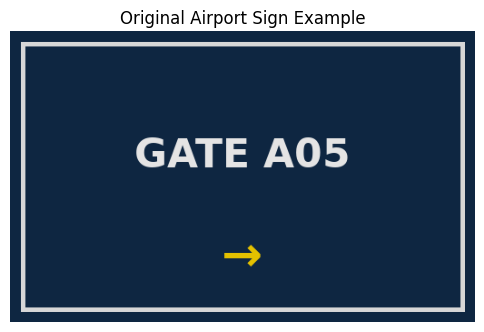

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(sample_image)
plt.title("Original Airport Sign Example")
plt.axis("off")
plt.show()

## 4.4 Airport Category Prompts

Each image category uses a few short text prompts so the result is not based on only one wording.


In [ ]:
CATEGORY_PROMPTS = {
    "gate": ["an airport gate sign", "a departure gate sign", "airport departure gates"],
    "baggage_claim": ["an airport baggage claim sign", "a luggage collection sign", "an airport baggage hall sign"],
    "check_in": ["an airport check-in sign", "airline check-in desks", "airport check-in counters"],
    "security": ["an airport security sign", "an airport security checkpoint", "passenger security screening"],
    "lounge": ["an airport lounge sign", "a passenger lounge", "an airport business lounge"],
    "restaurant": ["an airport restaurant sign", "an airport food court", "airport food and dining"],
    "transport": ["an airport transport sign", "an airport train station", "airport taxi and ground transport"],
    "information": ["an airport information sign", "an airport information desk", "airport passenger information"],
    "lost_and_found": ["an airport lost and found sign", "airport lost property", "airport lost items office"],
    "special_assistance": ["an airport special assistance sign", "airport accessibility services", "passenger mobility assistance"],
}

print("Visual categories:", len(CATEGORY_PROMPTS))


Visual categories: 10


In [ ]:
import torch.nn.functional as F
import numpy as np

category_names = list(CATEGORY_PROMPTS)
category_embeddings = []

with torch.no_grad():
    for category in category_names:
        inputs = clip_processor(
            text=CATEGORY_PROMPTS[category],
            return_tensors="pt",
            padding=True
        )
        inputs = {key: value.to(device) for key, value in inputs.items()}
        text_outputs = clip_model.get_text_features(**inputs)
        text_features = F.normalize(text_outputs.pooler_output, dim=-1)
        category_feature = F.normalize(
            text_features.mean(dim=0, keepdim=True),
            dim=-1
        )
        category_embeddings.append(category_feature.cpu().numpy()[0])

category_embeddings = np.asarray(category_embeddings, dtype="float32")
print("Category embedding shape:", category_embeddings.shape)


Category embedding shape: (10, 512)


## 4.5 CLIP FAISS Index

Normalised CLIP category embeddings are stored in a FAISS inner-product index for cosine-similarity ranking.


In [ ]:
import faiss

clip_embedding_dimension = (
    category_embeddings.shape[1]
)

clip_index = faiss.IndexFlatIP(
    clip_embedding_dimension
)

clip_index.add(
    category_embeddings
)

print("CLIP FAISS index created.")
print(
    "Embedding dimension:",
    clip_embedding_dimension
)
print(
    "Indexed categories:",
    clip_index.ntotal
)

CLIP FAISS index created.
Embedding dimension: 512
Indexed categories: 10


In [ ]:
clip_index_path = (
    DATA_DIR /
    "clip_category_index.faiss"
)

faiss.write_index(
    clip_index,
    str(clip_index_path)
)

print(
    "Saved:",
    clip_index_path
)

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/data/clip_category_index.faiss


In [ ]:
def encode_image(image):
    if isinstance(image, (str, Path)):
        image = Image.open(image).convert("RGB")

    inputs = clip_processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        image_outputs = clip_model.get_image_features(pixel_values=pixel_values)
        image_features = image_outputs.pooler_output

    image_features = F.normalize(image_features, dim=-1)
    return image_features.cpu().numpy().astype("float32")


In [ ]:
def classify_image(image, top_k=3):
    scores, indices = clip_index.search(encode_image(image), top_k)
    return [
        {"category": category_names[index], "similarity": float(score)}
        for score, index in zip(scores[0], indices[0])
    ]


In [ ]:
test_image = (
    IMAGE_DIR /
    "gate" /
    "gate_01.png"
)

vision_results = classify_image(
    test_image,
    top_k=3
)

print(
    "Image:",
    test_image.name
)

display(
    pd.DataFrame(
        vision_results
    )
)

Image: gate_01.png


,category,similarity
0,gate,0.335029
1,baggage_claim,0.285061
2,information,0.284035


In [ ]:
test_image = (
    IMAGE_DIR /
    "baggage_claim" /
    "baggage_claim_01.png"
)

vision_results = classify_image(
    test_image,
    top_k=3
)

display(
    pd.DataFrame(
        vision_results
    )
)

,category,similarity
0,baggage_claim,0.333796
1,gate,0.295159
2,check_in,0.285703


In [ ]:
test_image = (
    IMAGE_DIR /
    "special_assistance" /
    "special_assistance_01.png"
)

vision_results = classify_image(
    test_image,
    top_k=3
)

display(
    pd.DataFrame(
        vision_results
    )
)

,category,similarity
0,special_assistance,0.325465
1,baggage_claim,0.227552
2,security,0.219643


## 4.6 Category to Knowledge-Base Mapping

The detected image category is used to return matching KB records. Exact gates or terminals are resolved from text/voice context when available.


In [ ]:
def get_kb_candidates(category):
    return [record for record in airport_kb if record["category"] == category]


In [ ]:
candidates = get_kb_candidates(
    "lounge"
)

for record in candidates:
    print(
        record["record_id"],
        "->",
        record["name"]
    )

sky_lounge_t1 -> Sky Lounge
business_lounge_t2 -> Business Lounge


In [ ]:
def analyse_airport_image(image, top_k=3):
    predictions = classify_image(image, top_k=top_k)
    best_category = predictions[0]["category"]

    return {
        "predictions": predictions,
        "best_category": best_category,
        "kb_candidates": get_kb_candidates(best_category),
    }


In [ ]:
image_result = (
    analyse_airport_image(
        IMAGE_DIR /
        "lounge" /
        "lounge_01.png"
    )
)

print(
    "Best category:",
    image_result[
        "best_category"
    ]
)

print("\nTop-3:")
display(
    pd.DataFrame(
        image_result[
            "predictions"
        ]
    )
)

print(
    "\nMatching KB records:"
)

for record in (
    image_result[
        "kb_candidates"
    ]
):
    print(
        "-",
        record["name"]
    )

Best category: lounge

Top-3:


,category,similarity
0,lounge,0.311529
1,gate,0.278618
2,transport,0.277200



Matching KB records:
- Sky Lounge
- Business Lounge


## 4.7 Development Vision Check

Test the 40 development images here. The 20 evaluation images stay untouched until Phase 7.


In [ ]:
vision_development_results = []

for _, row in development_images.iterrows():
    predictions = classify_image(row["filepath"], top_k=3)
    top1 = predictions[0]["category"]
    top3 = [result["category"] for result in predictions]

    vision_development_results.append({
        "filename": row["filename"],
        "expected_category": row["category"],
        "predicted_top1": top1,
        "top1_correct": top1 == row["category"],
        "predicted_top3": " | ".join(top3),
        "top3_correct": row["category"] in top3,
        "top1_similarity": predictions[0]["similarity"],
    })

vision_development_df = pd.DataFrame(vision_development_results)
display(vision_development_df)


,filename,expected_category,predicted_top1,top1_correct,predicted_top3,top3_correct,top1_similarity
0,gate_01.png,gate,gate,True,gate | baggage_claim | information,True,0.335029
1,gate_02.png,gate,gate,True,gate | baggage_claim | information,True,0.332185
2,gate_03.png,gate,gate,True,gate | information | transport,True,0.312705
3,gate_04.png,gate,gate,True,gate | information | transport,True,0.320929
4,baggage_claim_01.png,baggage_claim,baggage_claim,True,baggage_claim | gate | check_in,True,0.333796
5,baggage_claim_02.png,baggage_claim,baggage_claim,True,baggage_claim | check_in | gate,True,0.323270
6,baggage_claim_03.png,baggage_claim,baggage_claim,True,baggage_claim | gate | check_in,True,0.310659
7,baggage_claim_04.png,baggage_claim,baggage_claim,True,baggage_claim | lounge | lost_and_found,True,0.303132
8,check_in_01.png,check_in,check_in,True,check_in | security | information,True,0.303494
9,check_in_02.png,check_in,check_in,True,check_in | security | special_assistance,True,0.288832


In [ ]:
vision_top1_accuracy = (
    vision_development_df[
        "top1_correct"
    ].mean()
)

vision_top3_accuracy = (
    vision_development_df[
        "top3_correct"
    ].mean()
)

print(
    "Development Top-1 accuracy:",
    f"{vision_top1_accuracy:.2%}"
)

print(
    "Development Top-3 accuracy:",
    f"{vision_top3_accuracy:.2%}"
)

Development Top-1 accuracy: 92.50%
Development Top-3 accuracy: 97.50%


In [ ]:
vision_dev_path = (
    PROJECT_DIR /
    "evaluation" /
    "vision_development_check.csv"
)

vision_development_df.to_csv(
    vision_dev_path,
    index=False
)

print(
    "Saved:",
    vision_dev_path
)

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/evaluation/vision_development_check.csv


In [ ]:
incorrect_vision = (
    vision_development_df[
        vision_development_df[
            "top1_correct"
        ] == False
    ]
)

print(
    "Incorrect Top-1 cases:",
    len(incorrect_vision)
)

display(
    incorrect_vision
)

Incorrect Top-1 cases: 3


,filename,expected_category,predicted_top1,top1_correct,predicted_top3,top3_correct,top1_similarity
22,restaurant_03.png,restaurant,transport,False,transport | gate | information,False,0.331816
30,information_03.png,information,special_assistance,False,special_assistance | information | baggage_claim,True,0.311882
35,lost_and_found_04.png,lost_and_found,security,False,security | special_assistance | lost_and_found,True,0.245000


### CLIP Similarity Score

The CLIP score is used for ranking categories and is not a calibrated probability.


## 4.8 Modular Image Processor

The vision pipeline is saved in `image_processor.py` for reuse by the multimodal assistant and Streamlit app.


In [ ]:
%%writefile image_processor.py

import json
from pathlib import Path

import faiss
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import CLIPModel, CLIPProcessor


CATEGORY_PROMPTS = {
    "gate": ["an airport gate sign", "a departure gate sign", "airport departure gates"],
    "baggage_claim": ["an airport baggage claim sign", "a luggage collection sign", "an airport baggage hall sign"],
    "check_in": ["an airport check-in sign", "airline check-in desks", "airport check-in counters"],
    "security": ["an airport security sign", "an airport security checkpoint", "passenger security screening"],
    "lounge": ["an airport lounge sign", "a passenger lounge", "an airport business lounge"],
    "restaurant": ["an airport restaurant sign", "an airport food court", "airport food and dining"],
    "transport": ["an airport transport sign", "an airport train station", "airport taxi and ground transport"],
    "information": ["an airport information sign", "an airport information desk", "airport passenger information"],
    "lost_and_found": ["an airport lost and found sign", "airport lost property", "airport lost items office"],
    "special_assistance": ["an airport special assistance sign", "airport accessibility services", "passenger mobility assistance"],
}


class ImageProcessor:
    def __init__(
        self,
        kb_path,
        model_name="openai/clip-vit-base-patch32",
        device=None,
    ):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CLIPModel.from_pretrained(model_name).to(self.device)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model.eval()

        with open(kb_path, "r", encoding="utf-8") as f:
            self.knowledge_base = json.load(f)

        self.category_names = list(CATEGORY_PROMPTS)
        self.category_embeddings = self._build_category_embeddings()
        self.index = faiss.IndexFlatIP(self.category_embeddings.shape[1])
        self.index.add(self.category_embeddings)

    @staticmethod
    def _extract_features(output):
        if isinstance(output, torch.Tensor):
            return output
        if hasattr(output, "pooler_output"):
            return output.pooler_output
        if isinstance(output, (tuple, list)):
            return output[0]
        raise TypeError(f"Unsupported CLIP output type: {type(output)}")

    def _build_category_embeddings(self):
        embeddings = []
        with torch.no_grad():
            for category in self.category_names:
                inputs = self.processor(
                    text=CATEGORY_PROMPTS[category],
                    return_tensors="pt",
                    padding=True,
                )
                inputs = {key: value.to(self.device) for key, value in inputs.items()}
                features = self._extract_features(self.model.get_text_features(**inputs))
                features = F.normalize(features, dim=-1)
                category_feature = F.normalize(features.mean(dim=0, keepdim=True), dim=-1)
                embeddings.append(category_feature.cpu().numpy()[0])
        return np.asarray(embeddings, dtype="float32")

    def encode_image(self, image):
        if isinstance(image, (str, Path)):
            image = Image.open(image).convert("RGB")

        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(self.device)
        with torch.no_grad():
            features = self._extract_features(
                self.model.get_image_features(pixel_values=pixel_values)
            )
        return F.normalize(features, dim=-1).cpu().numpy().astype("float32")

    def classify(self, image, top_k=3):
        scores, indices = self.index.search(self.encode_image(image), top_k)
        return [
            {"category": self.category_names[index], "similarity": float(score)}
            for score, index in zip(scores[0], indices[0])
        ]

    def get_kb_candidates(self, category):
        return [record for record in self.knowledge_base if record["category"] == category]

    def analyse(self, image, top_k=3):
        predictions = self.classify(image, top_k=top_k)
        best_category = predictions[0]["category"]
        return {
            "predictions": predictions,
            "best_category": best_category,
            "kb_candidates": self.get_kb_candidates(best_category),
        }


Overwriting image_processor.py


In [ ]:
from image_processor import ImageProcessor

module_image_processor = (
    ImageProcessor(
        kb_path=DATA_DIR /
        "airport_kb.json",
        device=device
    )
)

module_image_result = (
    module_image_processor.analyse(
        IMAGE_DIR /
        "gate" /
        "gate_01.png"
    )
)

print(
    "Best category:",
    module_image_result[
        "best_category"
    ]
)

print("\nTop-3:")

display(
    pd.DataFrame(
        module_image_result[
            "predictions"
        ]
    )
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Best category: gate

Top-3:


,category,similarity
0,gate,0.335029
1,baggage_claim,0.285061
2,information,0.284035


# Phase 5 — Speech Processing with Whisper

Audio is converted to 16 kHz mono, trimmed, transcribed with Whisper base, and then passed through the same text-retrieval pipeline.


In [ ]:
audio_df = pd.read_csv(DATA_DIR / "audio_metadata.csv")

print("Audio samples:", len(audio_df))
display(audio_df.head())

Audio samples: 10


,filename,filepath,reference_text,intent,expected_record
0,audio_01_gate.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is gate B twelve?,gate,gate_b12
1,audio_02_baggage.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is baggage claim in terminal one?,baggage_claim,baggage_t1
2,audio_03_checkin.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is check in at terminal two?,check_in,checkin_t2
3,audio_04_security.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,How do I reach security in terminal one?,security,security_t1
4,audio_05_lounge.wav,/content/drive/MyDrive/MMC_Airport_Assistant/d...,Where is the Sky Lounge?,lounge,sky_lounge_t1


## 5.1 Audio Preprocessing

Audio is loaded as 16 kHz mono and leading/trailing silence is trimmed. Extra noise reduction is not used because the current samples are clean.


In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

sample_audio_path = audio_df.iloc[0]["filepath"]

original_audio, original_sr = librosa.load(
    sample_audio_path,
    sr=None,
    mono=True
)

processed_audio, processed_sr = librosa.load(
    sample_audio_path,
    sr=16000,
    mono=True
)

trimmed_audio, _ = librosa.effects.trim(
    processed_audio,
    top_db=30
)

print("Original sample rate:", original_sr)
print("Processed sample rate:", processed_sr)

print(
    "Original duration:",
    round(len(original_audio) / original_sr, 2),
    "seconds"
)

print(
    "Trimmed duration:",
    round(len(trimmed_audio) / processed_sr, 2),
    "seconds"
)

Original sample rate: 22050
Processed sample rate: 16000
Original duration: 1.87 seconds
Trimmed duration: 1.5 seconds


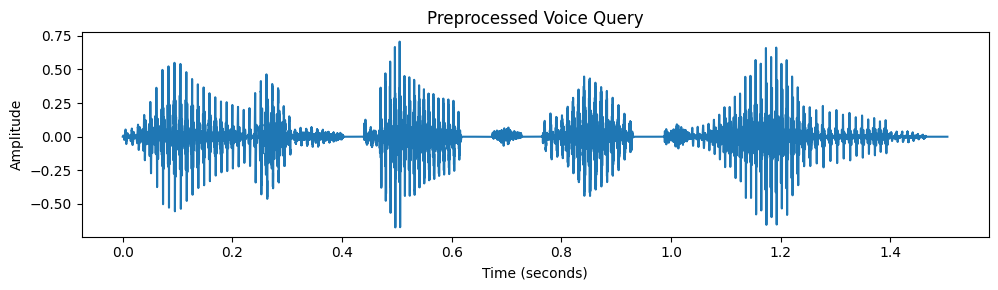

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/screenshots/audio_preprocessing_example.png


In [ ]:
times = np.arange(len(trimmed_audio)) / processed_sr

plt.figure(figsize=(10, 3))
plt.plot(times, trimmed_audio)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Preprocessed Voice Query")

plt.tight_layout()

audio_plot_path = (
    SCREENSHOT_DIR /
    "audio_preprocessing_example.png"
)

plt.savefig(
    audio_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", audio_plot_path)

## 5.2 Whisper Speech-to-Text

Use the pretrained Whisper base model without fine-tuning.


In [ ]:
import whisper
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading Whisper base...")
print("Device:", device)

whisper_model = whisper.load_model(
    "base",
    device=device
)

print("Whisper loaded successfully.")

Loading Whisper base...
Device: cuda
Whisper loaded successfully.


In [ ]:
result = whisper_model.transcribe(
    trimmed_audio,
    language="en",
    fp16=(device == "cuda")
)

transcript = result["text"].strip()

print("Reference:")
print(audio_df.iloc[0]["reference_text"])

print("\nWhisper transcript:")
print(transcript)

Reference:
Where is gate B twelve?

Whisper transcript:
Where is Gate B12?


In [ ]:
from text_processor import TextProcessor

voice_text_processor = TextProcessor(
    kb_path=DATA_DIR / "airport_kb.json",
    device=device
)

retrieval = voice_text_processor.retrieve(
    transcript,
    top_k=1
)

print("Transcript:", transcript)
print("Intent:", retrieval["intent"])

if retrieval["results"]:
    print(
        "Retrieved record:",
        retrieval["results"][0]["name"]
    )

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Transcript: Where is Gate B12?
Intent: gate
Retrieved record: Gate B12


In [ ]:
def transcribe_audio(path):
    audio, sr = librosa.load(
        path,
        sr=16000,
        mono=True
    )

    audio, _ = librosa.effects.trim(
        audio,
        top_db=30
    )

    result = whisper_model.transcribe(
        audio,
        language="en",
        fp16=(device == "cuda")
    )

    return result["text"].strip()

In [ ]:
import re

def normalize_transcript(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
print(
    normalize_transcript(
        "Where is Gate B12?"
    )
)

where is gate b12


In [ ]:
from jiwer import wer

speech_results = []

for _, row in audio_df.iterrows():

    transcript = transcribe_audio(
        row["filepath"]
    )

    retrieval = voice_text_processor.retrieve(
        transcript,
        top_k=1
    )

    predicted_record = (
        retrieval["results"][0]["record_id"]
        if retrieval["results"]
        else None
    )

    reference_clean = normalize_transcript(
        row["reference_text"]
    )

    transcript_clean = normalize_transcript(
        transcript
    )

    sample_wer = wer(
        reference_clean,
        transcript_clean
    )

    speech_results.append({
        "filename": row["filename"],
        "reference_text": row["reference_text"],
        "transcript": transcript,
        "expected_record": row["expected_record"],
        "predicted_record": predicted_record,
        "retrieval_correct":
            predicted_record == row["expected_record"],
        "wer": sample_wer
    })

speech_results_df = pd.DataFrame(
    speech_results
)

display(speech_results_df)

,filename,reference_text,transcript,expected_record,predicted_record,retrieval_correct,wer
0,audio_01_gate.wav,Where is gate B twelve?,Where is Gate B12?,gate_b12,gate_b12,True,0.400000
1,audio_02_baggage.wav,Where is baggage claim in terminal one?,Where is Bargage Clayman Terminal 1?,baggage_t1,food_court_t1,False,0.571429
2,audio_03_checkin.wav,Where is check in at terminal two?,"Well, is check it out, Terminal 2.",checkin_t2,checkin_t2,True,0.571429
3,audio_04_security.wav,How do I reach security in terminal one?,How do I reach security in Terminal 1?,security_t1,security_t1,True,0.125000
4,audio_05_lounge.wav,Where is the Sky Lounge?,Where is the sky lounge?,sky_lounge_t1,sky_lounge_t1,True,0.000000
5,audio_06_restaurant.wav,Where can I get food in terminal one?,Where can I get food in Terminal 1?,food_court_t1,food_court_t1,True,0.125000
6,audio_07_transport.wav,How do I get to the train station?,How do I get to the train station?,train_station,train_station,True,0.000000
7,audio_08_information.wav,Where is the information desk in terminal two?,Where is the information mask in Terminal 2?,info_t2,info_t2,True,0.250000
8,audio_09_lost.wav,Where can I report a lost bag?,Where can I report a lost buy?,lost_found,lost_found,True,0.142857
9,audio_10_assistance.wav,I need wheelchair assistance.,I need wheel care assistance.,special_assistance,special_assistance,True,0.500000


In [ ]:
references = [
    normalize_transcript(text)
    for text in speech_results_df[
        "reference_text"
    ]
]

hypotheses = [
    normalize_transcript(text)
    for text in speech_results_df[
        "transcript"
    ]
]

overall_wer = wer(
    references,
    hypotheses
)

retrieval_accuracy = (
    speech_results_df[
        "retrieval_correct"
    ].mean()
)

print(
    "Overall Word Error Rate:",
    f"{overall_wer:.2%}"
)

print(
    "Voice-to-KB retrieval accuracy:",
    f"{retrieval_accuracy:.2%}"
)

Overall Word Error Rate: 25.37%
Voice-to-KB retrieval accuracy: 90.00%


In [ ]:
speech_errors = speech_results_df[
    (speech_results_df["wer"] > 0)
    |
    (
        speech_results_df[
            "retrieval_correct"
        ] == False
    )
]

print(
    "Samples with transcription or retrieval errors:",
    len(speech_errors)
)

display(speech_errors)

Samples with transcription or retrieval errors: 8


,filename,reference_text,transcript,expected_record,predicted_record,retrieval_correct,wer
0,audio_01_gate.wav,Where is gate B twelve?,Where is Gate B12?,gate_b12,gate_b12,True,0.400000
1,audio_02_baggage.wav,Where is baggage claim in terminal one?,Where is Bargage Clayman Terminal 1?,baggage_t1,food_court_t1,False,0.571429
2,audio_03_checkin.wav,Where is check in at terminal two?,"Well, is check it out, Terminal 2.",checkin_t2,checkin_t2,True,0.571429
3,audio_04_security.wav,How do I reach security in terminal one?,How do I reach security in Terminal 1?,security_t1,security_t1,True,0.125000
5,audio_06_restaurant.wav,Where can I get food in terminal one?,Where can I get food in Terminal 1?,food_court_t1,food_court_t1,True,0.125000
7,audio_08_information.wav,Where is the information desk in terminal two?,Where is the information mask in Terminal 2?,info_t2,info_t2,True,0.250000
8,audio_09_lost.wav,Where can I report a lost bag?,Where can I report a lost buy?,lost_found,lost_found,True,0.142857
9,audio_10_assistance.wav,I need wheelchair assistance.,I need wheel care assistance.,special_assistance,special_assistance,True,0.500000


In [ ]:
speech_results_path = (
    PROJECT_DIR /
    "evaluation" /
    "speech_transcription_results.csv"
)

speech_results_df.to_csv(
    speech_results_path,
    index=False
)

print("Saved:", speech_results_path)

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/evaluation/speech_transcription_results.csv


### Speech Limitations

The voice set is synthetic, so WER may be different for real accents, unclear speech and noisy airport environments.


In [ ]:
%%writefile audio_processor.py

import librosa
import torch
import whisper

from text_processor import TextProcessor


class AudioProcessor:
    def __init__(
        self,
        kb_path,
        model_size="base",
        device=None,
        text_processor=None,
    ):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.whisper_model = whisper.load_model(model_size, device=self.device)
        self.text_processor = text_processor or TextProcessor(kb_path, device=self.device)

    def transcribe(self, audio_path):
        audio, _ = librosa.load(audio_path, sr=16000, mono=True)
        audio, _ = librosa.effects.trim(audio, top_db=30)
        result = self.whisper_model.transcribe(
            audio,
            language="en",
            fp16=(self.device == "cuda"),
        )
        return result["text"].strip()

    def analyse(self, audio_path):
        transcript = self.transcribe(audio_path)
        retrieval = self.text_processor.retrieve(transcript, top_k=1)

        if retrieval["intent"] is None:
            return {
                "transcript": transcript,
                "intent": None,
                "entities": retrieval["entities"],
                "results": [],
                "status": "uncertain",
            }

        return {
            "transcript": transcript,
            "intent": retrieval["intent"],
            "entities": retrieval["entities"],
            "results": retrieval["results"],
            "status": "matched",
        }


Overwriting audio_processor.py


In [ ]:
import importlib
import audio_processor as audio_processor_module

#fixed: reload the edited module before testing it
importlib.reload(audio_processor_module)
AudioProcessor = audio_processor_module.AudioProcessor

audio_processor = AudioProcessor(
    kb_path=DATA_DIR / "airport_kb.json",
    device=device
)

audio_result = audio_processor.analyse(
    AUDIO_DIR / "audio_02_baggage.wav"
)

print("Transcript:", audio_result["transcript"])
print("Intent:", audio_result["intent"])

#fixed: do not display an unrelated service when the voice result is uncertain
if audio_result["results"]:
    print("Result:", audio_result["results"][0]["name"])
else:
    print("Result: No reliable airport service match.")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Transcript: Where is Bargage Clayman Terminal 1?
Intent: None
Result: No reliable airport service match.


# Phase 6 — Multimodal Fusion

Text and transcribed voice provide the main intent/entity information, while CLIP provides image-category context. Fusion is done at decision level because MiniLM and CLIP use different embedding spaces.


## 6.1 Fusion Strategy

- Text: text retrieval
- Voice: Whisper → text retrieval
- Image: CLIP category → KB candidates
- Combined input: text/voice stays primary and the image checks whether the modalities agree

If the modalities disagree, the system reports a mismatch instead of silently changing the more specific text/voice request.


In [ ]:
%%writefile multimodal_assistant.py

from audio_processor import AudioProcessor
from image_processor import ImageProcessor
from text_processor import TextProcessor


class MultimodalAssistant:
    def __init__(self, kb_path, device=None):
        self.text_processor = TextProcessor(kb_path, device=device)
        self.image_processor = ImageProcessor(kb_path, device=device)
        self.audio_processor = AudioProcessor(
            kb_path,
            device=device,
            text_processor=self.text_processor,
        )

    @staticmethod
    def build_response(record):
        return (
            f"{record['name']}. {record['description']} "
            f"Directions: {record['directions']} "
            f"Opening hours: {record['opening_hours']} "
            f"Accessibility: {record['accessibility']}"
        )

    def process(self, text=None, image=None, audio_path=None):
        transcript = self.audio_processor.transcribe(audio_path) if audio_path else None
        query = (text or transcript or "").strip()
        text_result = self.text_processor.retrieve(query, top_k=3) if query else None
        image_result = self.image_processor.analyse(image, top_k=3) if image is not None else None

        result = {
            "input_text": text,
            "transcript": transcript,
            "text_intent": text_result["intent"] if text_result else None,
            "image_category": image_result["best_category"] if image_result else None,
            "text_similarity": None,
            "image_similarity": None,
            "status": "uncertain",
            "record": None,
            "response": "No reliable airport service match.",
        }

        if text_result and text_result["results"]:
            result["text_similarity"] = text_result["results"][0]["similarity"]
        if image_result:
            result["image_similarity"] = image_result["predictions"][0]["similarity"]

        if text_result and text_result["intent"] and text_result["results"]:
            record = text_result["results"][0]
            result["status"] = "matched"
            if image_result:
                result["status"] = (
                    "multimodal_consistent"
                    if record["category"] == image_result["best_category"]
                    else "multimodal_mismatch"
                )
            result["record"] = record
            result["response"] = self.build_response(record)
            return result

        if image_result:
            candidates = image_result["kb_candidates"]
            if len(candidates) == 1:
                record = candidates[0]
                result.update({
                    "status": "image_match",
                    "record": record,
                    "response": self.build_response(record),
                })
            else:
                names = ", ".join(record["name"] for record in candidates)
                category = image_result["best_category"].replace("_", " ")
                result["status"] = "category_only"
                result["response"] = (
                    f"The image appears to show {category}. "
                    f"Possible matching services: {names}."
                )

        return result


Overwriting multimodal_assistant.py


In [ ]:
from multimodal_assistant import MultimodalAssistant

assistant = MultimodalAssistant(
    kb_path=DATA_DIR / "airport_kb.json",
    device=device
)

print("Multimodal assistant loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Multimodal assistant loaded.


In [ ]:
def show_fusion_result(result):

    print("Status:", result["status"])

    if result["transcript"]:
        print("Transcript:", result["transcript"])

    print("Text intent:", result["text_intent"])
    print("Image category:", result["image_category"])

    if result["record"]:
        print("Matched record:", result["record"]["name"])

    print("Response:")
    print(result["response"])

In [ ]:
text_only = assistant.process(
    text="Where is Gate B12?"
)

show_fusion_result(text_only)

Status: matched
Text intent: gate
Image category: None
Matched record: Gate B12
Response:
Gate B12. Passenger departure gate situated in Zone B. Directions: Pass security and follow the blue Zone B signs toward Gates B01-B20. Opening hours: According to flight schedule Accessibility: Lift and wheelchair-accessible route available.


In [ ]:
voice_only = assistant.process(
    audio_path=AUDIO_DIR / "audio_07_transport.wav"
)

show_fusion_result(voice_only)

Status: matched
Transcript: How do I get to the train station?
Text intent: transport
Image category: None
Matched record: Airport Train Station
Response:
Airport Train Station. Rail connection between the airport and the city centre. Directions: Follow Train Station signs from the arrivals hall and take the escalator or lift to Level -1. Opening hours: 04:30-01:00 Accessibility: Lift access and step-free platforms available.


In [ ]:
image_only = assistant.process(
    image=IMAGE_DIR /
    "special_assistance" /
    "special_assistance_01.png"
)

show_fusion_result(image_only)

Status: image_match
Text intent: None
Image category: special_assistance
Matched record: Special Assistance Desk
Response:
Special Assistance Desk. Support point for passengers requiring mobility or additional travel assistance. Directions: Located beside the Terminal 1 Information Desk near the main entrance. Opening hours: 04:30-23:30 Accessibility: Designed for passengers with reduced mobility and additional support needs.


In [ ]:
image_text = assistant.process(
    text="Where is the Sky Lounge?",
    image=IMAGE_DIR /
    "lounge" /
    "lounge_01.png"
)

show_fusion_result(image_text)

Status: multimodal_consistent
Text intent: lounge
Image category: lounge
Matched record: Sky Lounge
Response:
Sky Lounge. Passenger lounge offering seating, refreshments and Wi-Fi. Directions: After security, follow signs toward Zone B and take the lift to the lounge level. Opening hours: 05:00-22:00 Accessibility: Wheelchair accessible.


In [ ]:
voice_image = assistant.process(
    audio_path=AUDIO_DIR / "audio_06_restaurant.wav",
    image=IMAGE_DIR /
    "restaurant" /
    "restaurant_01.png"
)

show_fusion_result(voice_image)

Status: multimodal_consistent
Transcript: Where can I get food in Terminal 1?
Text intent: restaurant
Image category: restaurant
Matched record: Terminal 1 Food Court
Response:
Terminal 1 Food Court. Food court offering several quick-service dining options. Directions: Located after security between Zones A and B. Opening hours: 05:00-22:00 Accessibility: Wheelchair accessible seating available.


In [ ]:
mismatch_test = assistant.process(
    text="Where can I get food in Terminal 1?",
    image=IMAGE_DIR /
    "gate" /
    "gate_01.png"
)

show_fusion_result(mismatch_test)

Status: multimodal_mismatch
Text intent: restaurant
Image category: gate
Matched record: Terminal 1 Food Court
Response:
Terminal 1 Food Court. Food court offering several quick-service dining options. Directions: Located after security between Zones A and B. Opening hours: 05:00-22:00 Accessibility: Wheelchair accessible seating available.


In [ ]:
fusion_tests = [
    ("Text only", "gate_b12", text_only),
    ("Voice only", "train_station", voice_only),
    ("Image only", "special_assistance", image_only),
    ("Image + Text", "sky_lounge_t1", image_text),
    ("Voice + Image", "food_court_t1", voice_image),
    ("Mismatch test", "food_court_t1", mismatch_test)
]

fusion_rows = []

for scenario, expected, result in fusion_tests:

    predicted = (
        result["record"]["record_id"]
        if result["record"] else None
    )

    fusion_rows.append({
        "scenario": scenario,
        "expected_record": expected,
        "predicted_record": predicted,
        "status": result["status"],
        "text_intent": result["text_intent"],
        "image_category": result["image_category"],
        "correct": predicted == expected
    })

fusion_development_df = pd.DataFrame(fusion_rows)

display(fusion_development_df)

print(
    "Fusion development accuracy:",
    f"{fusion_development_df['correct'].mean():.2%}"
)

,scenario,expected_record,predicted_record,status,text_intent,image_category,correct
0,Text only,gate_b12,gate_b12,matched,gate,None,True
1,Voice only,train_station,train_station,matched,transport,None,True
2,Image only,special_assistance,special_assistance,image_match,None,special_assistance,True
3,Image + Text,sky_lounge_t1,sky_lounge_t1,multimodal_consistent,lounge,lounge,True
4,Voice + Image,food_court_t1,food_court_t1,multimodal_consistent,restaurant,restaurant,True
5,Mismatch test,food_court_t1,food_court_t1,multimodal_mismatch,restaurant,gate,True


Fusion development accuracy: 100.00%


In [ ]:
fusion_path = (
    PROJECT_DIR /
    "evaluation" /
    "fusion_development_check.csv"
)

fusion_development_df.to_csv(
    fusion_path,
    index=False
)

print("Saved:", fusion_path)

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/evaluation/fusion_development_check.csv


# Phase 7 — Formal Evaluation

Use the held-out evaluation data to measure the finished pipelines. No further tuning is done from these results.


In [ ]:
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

EVAL_DIR = PROJECT_DIR / "evaluation"

text_eval_data = text_df[
    text_df["split"] == "evaluation"
].copy()

text_eval_rows = []

for _, row in text_eval_data.iterrows():
    result = assistant.text_processor.retrieve(
        row["query"],
        top_k=1
    )

    predicted_record = (
        result["results"][0]["record_id"]
        if result["results"] else None
    )

    similarity = (
        result["results"][0]["similarity"]
        if result["results"] else None
    )

    text_eval_rows.append({
        "query": row["query"],
        "expected_intent": row["intent"],
        "predicted_intent": result["intent"],
        "expected_record": row["expected_record"],
        "predicted_record": predicted_record,
        "similarity": similarity,
        "intent_correct": result["intent"] == row["intent"],
        "retrieval_correct": predicted_record == row["expected_record"]
    })

text_evaluation_df = pd.DataFrame(text_eval_rows)
display(text_evaluation_df)

text_intent_accuracy = text_evaluation_df["intent_correct"].mean()
text_retrieval_accuracy = text_evaluation_df["retrieval_correct"].mean()

print("Text intent accuracy:", f"{text_intent_accuracy:.2%}")
print("Text retrieval accuracy:", f"{text_retrieval_accuracy:.2%}")

,query,expected_intent,predicted_intent,expected_record,predicted_record,similarity,intent_correct,retrieval_correct
0,Where is Gate B12?,gate,gate,gate_b12,gate_b12,0.708799,True,True
1,I need to find Gate C07.,gate,gate,gate_c07,gate_c07,0.690382,True,True
2,Where is baggage claim in Terminal 1?,baggage_claim,baggage_claim,baggage_t1,baggage_t1,0.670786,True,True
3,Where can I collect my luggage in Terminal 2?,baggage_claim,baggage_claim,baggage_t2,baggage_t2,0.570523,True,True
4,Where is check-in in Terminal 1?,check_in,check_in,checkin_t1,checkin_t1,0.642025,True,True
5,How do I reach the Terminal 2 check-in desks?,check_in,check_in,checkin_t2,checkin_t2,0.654508,True,True
6,Where is security in Terminal 1?,security,security,security_t1,security_t1,0.714765,True,True
7,How can I reach Terminal 2 security?,security,security,security_t2,security_t2,0.638797,True,True
8,Where is the Sky Lounge?,lounge,lounge,sky_lounge_t1,sky_lounge_t1,0.713084,True,True
9,Is there a lounge in Terminal 2?,lounge,lounge,business_lounge_t2,business_lounge_t2,0.682875,True,True


Text intent accuracy: 100.00%
Text retrieval accuracy: 100.00%


In [ ]:
true_intents = text_evaluation_df["expected_intent"]
predicted_intents = text_evaluation_df["predicted_intent"].fillna("unknown")

report = classification_report(
    true_intents,
    predicted_intents,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

text_macro_f1 = report["macro avg"]["f1-score"]

print("Macro F1:", f"{text_macro_f1:.3f}")

,precision,recall,f1-score,support
baggage_claim,1.0,1.0,1.0,2.0
check_in,1.0,1.0,1.0,2.0
gate,1.0,1.0,1.0,2.0
information,1.0,1.0,1.0,2.0
lost_and_found,1.0,1.0,1.0,2.0
lounge,1.0,1.0,1.0,2.0
restaurant,1.0,1.0,1.0,2.0
security,1.0,1.0,1.0,2.0
special_assistance,1.0,1.0,1.0,2.0
transport,1.0,1.0,1.0,2.0


Macro F1: 1.000


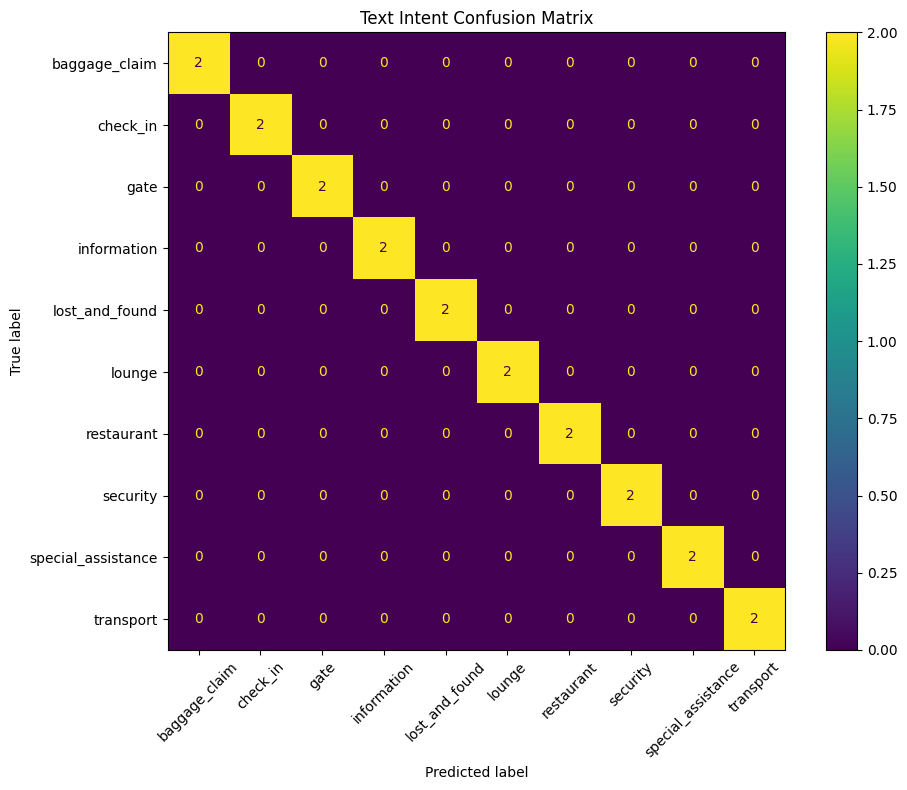

In [ ]:
labels = sorted(
    set(true_intents) |
    set(predicted_intents)
)

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    true_intents,
    predicted_intents,
    labels=labels,
    xticks_rotation=45,
    ax=ax
)

plt.title("Text Intent Confusion Matrix")
plt.tight_layout()

text_cm_path = (
    SCREENSHOT_DIR /
    "text_intent_confusion_matrix.png"
)

plt.savefig(text_cm_path, dpi=200)
plt.show()

In [ ]:
text_evaluation_df.to_csv(
    EVAL_DIR / "text_evaluation_results.csv",
    index=False
)

In [ ]:
vision_eval_data = image_df[
    image_df["split"] == "evaluation"
].copy()

vision_eval_rows = []

for _, row in vision_eval_data.iterrows():
    predictions = assistant.image_processor.classify(
        row["filepath"],
        top_k=3
    )

    top1 = predictions[0]["category"]
    top3 = [p["category"] for p in predictions]

    vision_eval_rows.append({
        "filename": row["filename"],
        "expected_category": row["category"],
        "predicted_top1": top1,
        "top1_similarity": predictions[0]["similarity"],
        "predicted_top3": " | ".join(top3),
        "top1_correct": top1 == row["category"],
        "top3_correct": row["category"] in top3
    })

vision_evaluation_df = pd.DataFrame(vision_eval_rows)
display(vision_evaluation_df)

vision_top1 = vision_evaluation_df["top1_correct"].mean()
vision_top3 = vision_evaluation_df["top3_correct"].mean()

print("Vision Top-1 accuracy:", f"{vision_top1:.2%}")
print("Vision Top-3 accuracy:", f"{vision_top3:.2%}")

,filename,expected_category,predicted_top1,top1_similarity,predicted_top3,top1_correct,top3_correct
0,gate_05.png,gate,gate,0.324727,gate | security | transport,True,True
1,gate_06.png,gate,gate,0.306183,gate | baggage_claim | special_assistance,True,True
2,baggage_claim_05.png,baggage_claim,baggage_claim,0.319016,baggage_claim | gate | special_assistance,True,True
3,baggage_claim_06.png,baggage_claim,baggage_claim,0.253033,baggage_claim | security | check_in,True,True
4,check_in_05.png,check_in,check_in,0.318558,check_in | security | information,True,True
5,check_in_06.png,check_in,check_in,0.320072,check_in | gate | security,True,True
6,security_05.png,security,security,0.340210,security | special_assistance | baggage_claim,True,True
7,security_06.png,security,security,0.306394,security | check_in | special_assistance,True,True
8,lounge_05.png,lounge,lounge,0.331135,lounge | baggage_claim | special_assistance,True,True
9,lounge_06.png,lounge,lounge,0.287215,lounge | check_in | security,True,True


Vision Top-1 accuracy: 90.00%
Vision Top-3 accuracy: 95.00%


In [ ]:
vision_failures = vision_evaluation_df[
    vision_evaluation_df["top1_correct"] == False
]

print("Incorrect Top-1 cases:", len(vision_failures))
display(vision_failures)

Incorrect Top-1 cases: 2


,filename,expected_category,predicted_top1,top1_similarity,predicted_top3,top1_correct,top3_correct
12,transport_05.png,transport,special_assistance,0.273218,special_assistance | transport | check_in,False,True
14,information_05.png,information,special_assistance,0.267001,special_assistance | check_in | lost_and_found,False,False


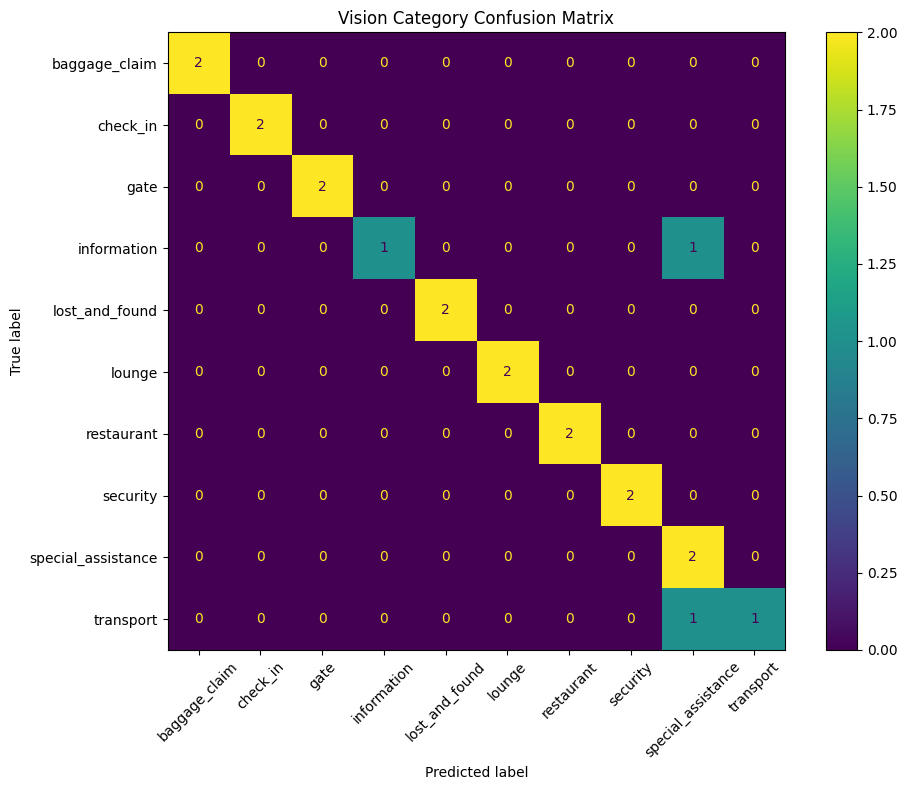

In [ ]:
vision_labels = sorted(
    image_df["category"].unique()
)

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    vision_evaluation_df["expected_category"],
    vision_evaluation_df["predicted_top1"],
    labels=vision_labels,
    xticks_rotation=45,
    ax=ax
)

plt.title("Vision Category Confusion Matrix")
plt.tight_layout()

vision_cm_path = (
    SCREENSHOT_DIR /
    "vision_confusion_matrix.png"
)

plt.savefig(vision_cm_path, dpi=200)
plt.show()

In [ ]:
vision_evaluation_df.to_csv(
    EVAL_DIR / "vision_evaluation_results.csv",
    index=False
)

In [ ]:
from jiwer import wer

speech_eval_df = pd.read_csv(
    EVAL_DIR /
    "speech_transcription_results.csv"
)

references = [
    normalize_transcript(x)
    for x in speech_eval_df["reference_text"]
]

hypotheses = [
    normalize_transcript(x)
    for x in speech_eval_df["transcript"]
]

speech_wer = wer(
    references,
    hypotheses
)

speech_retrieval_accuracy = (
    speech_eval_df[
        "retrieval_correct"
    ].mean()
)

print("Speech samples:", len(speech_eval_df))
print("Word Error Rate:", f"{speech_wer:.2%}")
print(
    "Voice-to-KB retrieval accuracy:",
    f"{speech_retrieval_accuracy:.2%}"
)

Speech samples: 10
Word Error Rate: 25.37%
Voice-to-KB retrieval accuracy: 90.00%


In [ ]:
fusion_eval_cases = [
    {
        "scenario": "Text only",
        "expected": "baggage_t2",
        "result": assistant.process(
            text="Where can I collect my luggage in Terminal 2?"
        )
    },
    {
        "scenario": "Voice only",
        "expected": "security_t1",
        "result": assistant.process(
            audio_path=AUDIO_DIR / "audio_04_security.wav"
        )
    },
    {
        "scenario": "Image only",
        "expected": "special_assistance",
        "result": assistant.process(
            image=IMAGE_DIR /
            "special_assistance" /
            "special_assistance_05.png"
        )
    },
    {
        "scenario": "Image + Text",
        "expected": "business_lounge_t2",
        "result": assistant.process(
            text="Is there a lounge in Terminal 2?",
            image=IMAGE_DIR / "lounge" / "lounge_05.png"
        )
    },
    {
        "scenario": "Voice + Image",
        "expected": "info_t2",
        "result": assistant.process(
            audio_path=AUDIO_DIR / "audio_08_information.wav",
            image=IMAGE_DIR /
            "information" /
            "information_05.png"
        )
    },
    {
        "scenario": "Mismatch stress test",
        "expected": "taxi_pickup",
        "result": assistant.process(
            text="Where can I get a taxi?",
            image=IMAGE_DIR / "gate" / "gate_05.png"
        )
    }
]

In [ ]:
fusion_eval_rows = []

for case in fusion_eval_cases:
    result = case["result"]

    predicted = (
        result["record"]["record_id"]
        if result["record"] else None
    )

    fusion_eval_rows.append({
        "scenario": case["scenario"],
        "expected_record": case["expected"],
        "predicted_record": predicted,
        "status": result["status"],
        "text_intent": result["text_intent"],
        "image_category": result["image_category"],
        "text_similarity": result["text_similarity"],
        "image_similarity": result["image_similarity"],
        "correct": predicted == case["expected"]
    })

fusion_evaluation_df = pd.DataFrame(fusion_eval_rows)
display(fusion_evaluation_df)

fusion_accuracy = fusion_evaluation_df["correct"].mean()

print(
    "Fusion evaluation accuracy:",
    f"{fusion_accuracy:.2%}"
)

,scenario,expected_record,predicted_record,status,text_intent,image_category,text_similarity,image_similarity,correct
0,Text only,baggage_t2,baggage_t2,matched,baggage_claim,None,0.570523,NaN,True
1,Voice only,security_t1,security_t1,matched,security,None,0.626230,NaN,True
2,Image only,special_assistance,special_assistance,image_match,None,special_assistance,NaN,0.281206,True
3,Image + Text,business_lounge_t2,business_lounge_t2,multimodal_consistent,lounge,lounge,0.682875,0.331135,True
4,Voice + Image,info_t2,info_t2,multimodal_mismatch,information,special_assistance,0.535098,0.267001,True
5,Mismatch stress test,taxi_pickup,taxi_pickup,multimodal_mismatch,transport,gate,0.390063,0.324727,True


Fusion evaluation accuracy: 100.00%


In [ ]:
fusion_evaluation_df.to_csv(
    EVAL_DIR / "fusion_evaluation_results.csv",
    index=False
)

In [ ]:
evaluation_summary = pd.DataFrame([
    ["Text intent accuracy", text_intent_accuracy],
    ["Text retrieval accuracy", text_retrieval_accuracy],
    ["Text macro F1", text_macro_f1],
    ["Vision Top-1 accuracy", vision_top1],
    ["Vision Top-3 accuracy", vision_top3],
    ["Speech retrieval accuracy", speech_retrieval_accuracy],
    ["Speech WER", speech_wer],
    ["Fusion accuracy", fusion_accuracy]
], columns=["metric", "value"])

display(evaluation_summary)

evaluation_summary.to_csv(
    EVAL_DIR / "evaluation_summary.csv",
    index=False
)

,metric,value
0,Text intent accuracy,1.000000
1,Text retrieval accuracy,1.000000
2,Text macro F1,1.000000
3,Vision Top-1 accuracy,0.900000
4,Vision Top-3 accuracy,0.950000
5,Speech retrieval accuracy,0.900000
6,Speech WER,0.253731
7,Fusion accuracy,1.000000


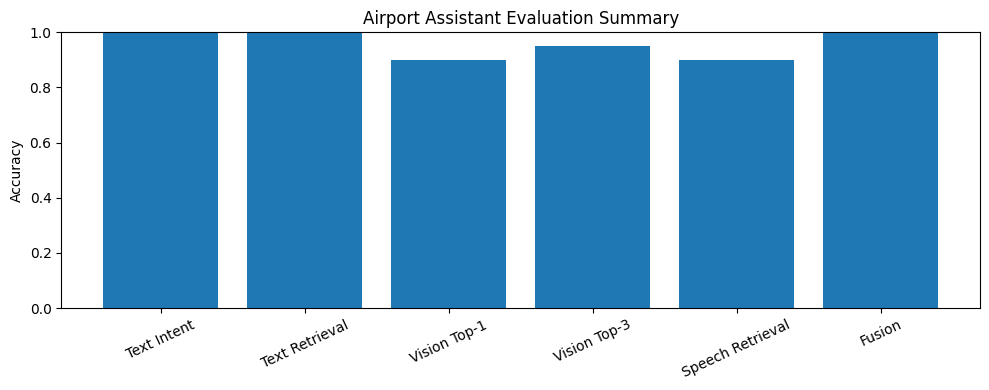

In [ ]:
accuracy_names = [
    "Text Intent",
    "Text Retrieval",
    "Vision Top-1",
    "Vision Top-3",
    "Speech Retrieval",
    "Fusion"
]

accuracy_values = [
    text_intent_accuracy,
    text_retrieval_accuracy,
    vision_top1,
    vision_top3,
    speech_retrieval_accuracy,
    fusion_accuracy
]

plt.figure(figsize=(10, 4))
plt.bar(accuracy_names, accuracy_values)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Airport Assistant Evaluation Summary")
plt.xticks(rotation=25)
plt.tight_layout()

evaluation_plot_path = (
    SCREENSHOT_DIR /
    "evaluation_accuracy_summary.png"
)

plt.savefig(
    evaluation_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print("Text retrieval failures:")
display(
    text_evaluation_df[
        text_evaluation_df["retrieval_correct"] == False
    ]
)

print("\nVision Top-1 failures:")
display(vision_failures)

print("\nSpeech retrieval failures:")
display(
    speech_eval_df[
        speech_eval_df["retrieval_correct"] == False
    ]
)

print("\nFusion failures:")
display(
    fusion_evaluation_df[
        fusion_evaluation_df["correct"] == False
    ]
)

Text retrieval failures:


,query,expected_intent,predicted_intent,expected_record,predicted_record,similarity,intent_correct,retrieval_correct



Vision Top-1 failures:


,filename,expected_category,predicted_top1,top1_similarity,predicted_top3,top1_correct,top3_correct
12,transport_05.png,transport,special_assistance,0.273218,special_assistance | transport | check_in,False,True
14,information_05.png,information,special_assistance,0.267001,special_assistance | check_in | lost_and_found,False,False



Speech retrieval failures:


,filename,reference_text,transcript,expected_record,predicted_record,retrieval_correct,wer
1,audio_02_baggage.wav,Where is baggage claim in terminal one?,Where is Bargage Clayman Terminal 1?,baggage_t1,food_court_t1,False,0.571429



Fusion failures:


,scenario,expected_record,predicted_record,status,text_intent,image_category,text_similarity,image_similarity,correct


### Evaluation Notes

Evaluation errors are kept as real failure cases rather than manually corrected.


# Phase 8 — Streamlit Deployment

The Streamlit prototype supports text, image and voice input and shows the retrieved service, similarity scores, transcripts and uncertainty/mismatch messages.


In [ ]:
%%writefile /content/drive/MyDrive/MMC_Airport_Assistant/app.py

from pathlib import Path
import os
import tempfile

import streamlit as st
from PIL import Image

from multimodal_assistant import MultimodalAssistant


PROJECT_DIR = Path(__file__).resolve().parent
KB_PATH = PROJECT_DIR / "data" / "airport_kb.json"

st.set_page_config(
    page_title="SkyPort Airport Assistant",
    page_icon="✈️",
    layout="wide",
)


@st.cache_resource
def load_assistant():
    return MultimodalAssistant(kb_path=KB_PATH)


assistant = load_assistant()

st.title("✈️ SkyPort Airport Assistant")
st.caption("Multimodal passenger assistance using text, airport-sign images and voice.")

with st.sidebar:
    st.subheader("About this prototype")
    st.write("This proof-of-concept assistant uses a fictional airport knowledge base.")
    st.info("The demo does not contain live flight, gate or operational airport information.")

input_col, result_col = st.columns(2)

with input_col:
    st.subheader("Passenger Input")
    text_query = st.text_input("Ask a question", placeholder="Example: Where is Gate B12?")
    image_file = st.file_uploader(
        "Upload an airport image",
        type=["png", "jpg", "jpeg"],
        key="image_upload",
    )
    recorded_audio = st.audio_input("Record a voice query")
    uploaded_audio = st.file_uploader(
        "Or upload an audio file",
        type=["wav", "mp3", "m4a"],
        key="audio_upload",
    )

    if image_file:
        st.image(image_file, caption="Uploaded image", use_container_width=True)

    audio_source = recorded_audio or uploaded_audio
    if audio_source:
        st.audio(audio_source)

    analyse = st.button("Ask Assistant", type="primary", use_container_width=True)

if analyse:
    if not text_query and not image_file and not audio_source:
        st.warning("Please provide text, an image or a voice query.")
    else:
        image = Image.open(image_file).convert("RGB") if image_file else None
        audio_path = None

        if audio_source:
            suffix = ".wav" if recorded_audio else Path(audio_source.name).suffix
            with tempfile.NamedTemporaryFile(delete=False, suffix=suffix or ".wav") as temp_audio:
                temp_audio.write(audio_source.getvalue())
                audio_path = temp_audio.name

        try:
            with st.spinner("Analysing passenger request..."):
                result = assistant.process(
                    text=text_query or None,
                    image=image,
                    audio_path=audio_path,
                )
        finally:
            if audio_path and os.path.exists(audio_path):
                os.remove(audio_path)

        with result_col:
            st.subheader("Assistant Response")

            if result["status"] == "uncertain":
                st.error("No reliable airport service match could be identified.")
            elif result["status"] == "multimodal_mismatch":
                st.warning(
                    "The supplied inputs do not fully agree. "
                    "The more specific text or voice request was used."
                )
            elif result["status"] == "category_only":
                st.info("The image identifies a service category, but not one unique airport location.")
            else:
                st.success("Airport service match found.")

            st.write(result["response"])

            if result["transcript"]:
                st.markdown("**Voice transcript**")
                st.write(result["transcript"])

            if result["record"]:
                record = result["record"]
                st.markdown("### Retrieved Service")
                st.write(f"**{record['name']}**")
                st.write(f"Terminal: {record['terminal']}")
                st.write(f"Location: {record['floor_zone']}")

            score_col1, score_col2 = st.columns(2)
            with score_col1:
                if result["text_similarity"] is not None:
                    st.metric("Text similarity", f"{result['text_similarity']:.3f}")
            with score_col2:
                if result["image_similarity"] is not None:
                    st.metric("Image similarity", f"{result['image_similarity']:.3f}")

            if result["text_intent"]:
                st.caption(f"Detected intent: {result['text_intent']}")
            if result["image_category"]:
                st.caption(f"Detected image category: {result['image_category']}")

st.divider()
st.caption("SkyPort International Airport — fictional academic proof-of-concept.")


Overwriting /content/drive/MyDrive/MMC_Airport_Assistant/app.py


In [ ]:
!python -m py_compile \
/content/drive/MyDrive/MMC_Airport_Assistant/app.py

print("Streamlit app syntax check passed.")

Streamlit app syntax check passed.


In [ ]:
%cd /content/drive/MyDrive/MMC_Airport_Assistant

/content


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --browser.gatherUsageStats false \
    > /content/streamlit.log 2>&1 &

In [ ]:
import time
time.sleep(5)

print("Streamlit started.")

Streamlit started.


In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

# Phase 9 — Architecture and Prototype Evidence

This phase saves the final architecture diagram and structured UI test evidence used in the report.


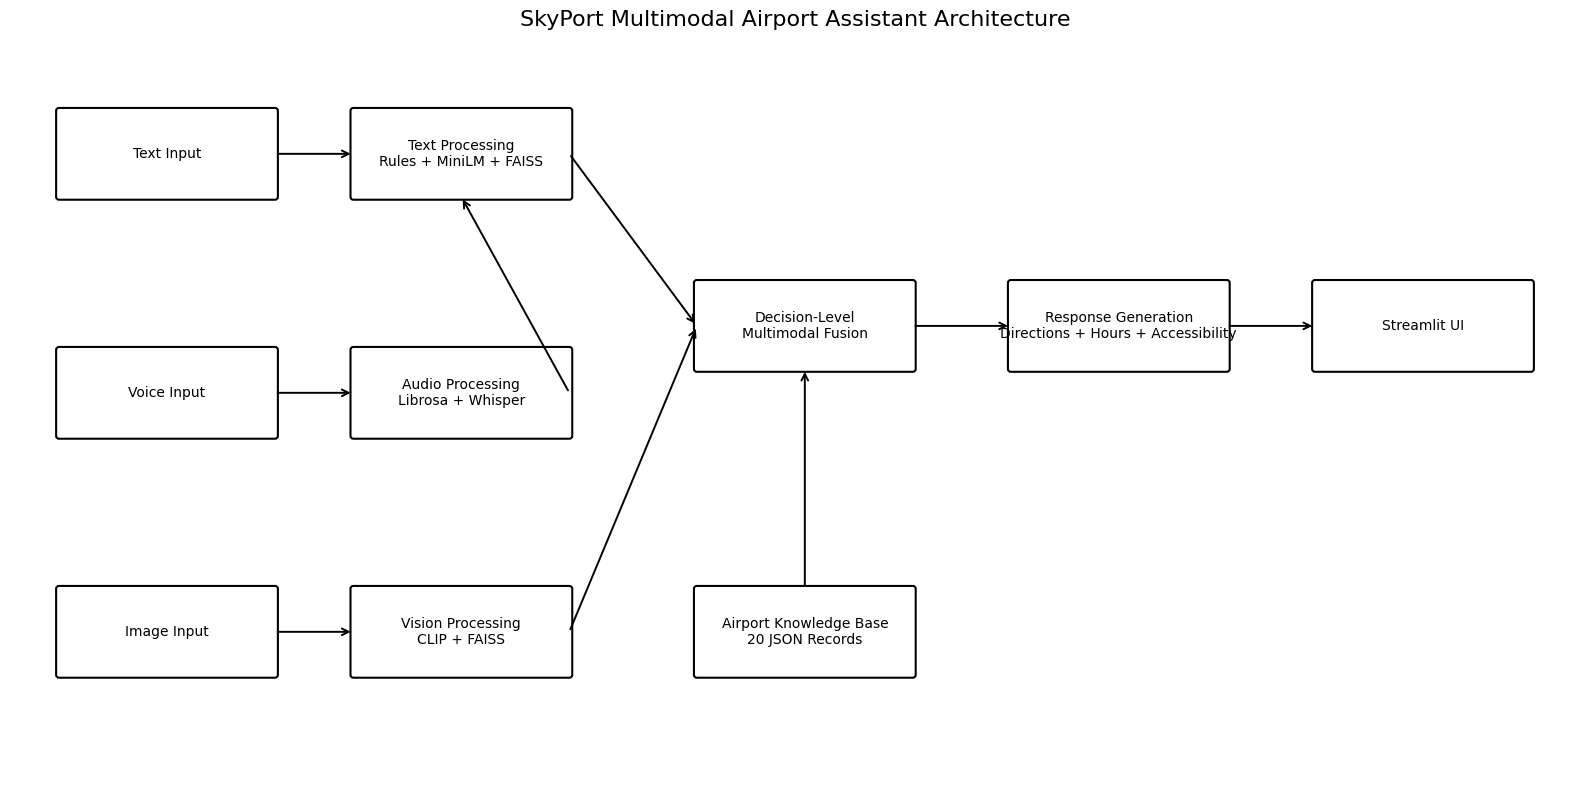

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/screenshots/system_architecture.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def add_box(ax, x, y, text, width=2.2, height=0.9):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        fill=False,
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=10
    )

    return {
        "left": (x, y + height / 2),
        "right": (x + width, y + height / 2),
        "top": (x + width / 2, y + height),
        "bottom": (x + width / 2, y)
    }


def connect(ax, start, end):
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="->",
            mutation_scale=12,
            linewidth=1.4
        )
    )


fig, ax = plt.subplots(figsize=(16, 8))

text_box = add_box(
    ax, 0.5, 6.6,
    "Text Input"
)

voice_box = add_box(
    ax, 0.5, 4.1,
    "Voice Input"
)

image_box = add_box(
    ax, 0.5, 1.6,
    "Image Input"
)

text_pipeline = add_box(
    ax, 3.5, 6.6,
    "Text Processing\nRules + MiniLM + FAISS"
)

whisper_box = add_box(
    ax, 3.5, 4.1,
    "Audio Processing\nLibrosa + Whisper"
)

clip_box = add_box(
    ax, 3.5, 1.6,
    "Vision Processing\nCLIP + FAISS"
)

fusion_box = add_box(
    ax, 7.0, 4.8,
    "Decision-Level\nMultimodal Fusion"
)

kb_box = add_box(
    ax, 7.0, 1.6,
    "Airport Knowledge Base\n20 JSON Records"
)

response_box = add_box(
    ax, 10.2, 4.8,
    "Response Generation\nDirections + Hours + Accessibility"
)

ui_box = add_box(
    ax, 13.3, 4.8,
    "Streamlit UI"
)

connect(ax, text_box["right"], text_pipeline["left"])
connect(ax, voice_box["right"], whisper_box["left"])
connect(ax, whisper_box["right"], text_pipeline["bottom"])
connect(ax, image_box["right"], clip_box["left"])

connect(ax, text_pipeline["right"], fusion_box["left"])
connect(ax, clip_box["right"], fusion_box["left"])

connect(ax, kb_box["top"], fusion_box["bottom"])

connect(ax, fusion_box["right"], response_box["left"])
connect(ax, response_box["right"], ui_box["left"])

ax.set_xlim(0, 16)
ax.set_ylim(0.5, 8.3)
ax.axis("off")

plt.title(
    "SkyPort Multimodal Airport Assistant Architecture",
    fontsize=16
)

plt.tight_layout()

architecture_path = (
    SCREENSHOT_DIR /
    "system_architecture.png"
)

plt.savefig(
    architecture_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", architecture_path)

### Architecture Summary

Text goes directly to the text pipeline; voice is first transcribed by Whisper and then uses the same text pipeline. Images are handled by CLIP + FAISS. The outputs are combined with decision-level rules and matched to the structured airport KB before the response is shown in Streamlit.


## 9.2 Structured Prototype User Testing

Six Streamlit scenarios cover text, voice, image, combined input, mismatch handling and uncertainty.


In [ ]:
EVAL_DIR = PROJECT_DIR / "evaluation"

ui_test_rows = [
    {
        "scenario": "Text only",
        "input_modality": "Text",
        "user_input": "Where is Gate B12?",
        "expected_response": "Return Gate B12 with terminal/location.",
        "actual_response": "Gate B12 returned in Terminal 1, Level 2 Zone B; similarity 0.709.",
        "correctness": True,
        "observed_limitation": "Static KB; no live gate changes.",
        "suggested_improvement": "Connect official live airport data.",
        "screenshot": "streamlit_text_response.png",
    },
    {
        "scenario": "Voice only",
        "input_modality": "Voice",
        "user_input": "Where is the airport train station?",
        "expected_response": "Transcribe speech and return Airport Train Station.",
        "actual_response": "Whisper transcribed correctly and returned Airport Train Station; similarity 0.714.",
        "correctness": True,
        "observed_limitation": "Synthetic/clean audio does not cover accents and airport noise.",
        "suggested_improvement": "Test real voices, accents and noisy recordings.",
        "screenshot": "streamlit_voice_response.png",
    },
    {
        "scenario": "Image only",
        "input_modality": "Image",
        "user_input": "special_assistance_05.png",
        "expected_response": "Recognise special assistance and return its desk.",
        "actual_response": "Special Assistance Desk returned; image similarity 0.281.",
        "correctness": True,
        "observed_limitation": "Similarity is a ranking score, not a probability.",
        "suggested_improvement": "Test more varied real airport images.",
        "screenshot": "streamlit_image_response.png",
    },
    {
        "scenario": "Image + Text",
        "input_modality": "Image + Text",
        "user_input": "lounge_05.png + Is there a lounge in Terminal 2?",
        "expected_response": "Return Business Lounge in Terminal 2.",
        "actual_response": "Business Lounge returned; text and image both matched lounge.",
        "correctness": True,
        "observed_limitation": "Image category alone may match more than one lounge.",
        "suggested_improvement": "Use terminal/location context when available.",
        "screenshot": "streamlit_multimodal_response.png",
    },
    {
        "scenario": "Multimodal mismatch",
        "input_modality": "Image + Text",
        "user_input": "gate_05.png + Where can I get a taxi?",
        "expected_response": "Return taxi service and warn about the mismatch.",
        "actual_response": "Taxi Pickup Zone returned with a mismatch warning.",
        "correctness": True,
        "observed_limitation": "Conflicting inputs need a routing rule.",
        "suggested_improvement": "Ask for clarification when evidence conflicts.",
        "screenshot": "streamlit_mismatch_response.png",
    },
    {
        "scenario": "Uncertainty",
        "input_modality": "Text",
        "user_input": "Hello there",
        "expected_response": "Do not return an unrelated airport service.",
        "actual_response": "No reliable airport-service match returned; similarity 0.105.",
        "correctness": True,
        "observed_limitation": "The prototype is not a general conversation bot.",
        "suggested_improvement": "Add a safe fallback or human handover.",
        "screenshot": "streamlit_uncertainty_response.png",
    },
]

ui_test_df = pd.DataFrame(ui_test_rows)
display(ui_test_df)


,scenario,input_modality,user_input,expected_response,actual_response,correctness,observed_limitation,suggested_improvement,screenshot
0,Text only,Text,Where is Gate B12?,Return Gate B12 with terminal/location.,"Gate B12 returned in Terminal 1, Level 2 Zone ...",True,Static KB; no live gate changes.,Connect official live airport data.,streamlit_text_response.png
1,Voice only,Voice,Where is the airport train station?,Transcribe speech and return Airport Train Sta...,Whisper transcribed correctly and returned Air...,True,Synthetic/clean audio does not cover accents a...,"Test real voices, accents and noisy recordings.",streamlit_voice_response.png
2,Image only,Image,special_assistance_05.png,Recognise special assistance and return its desk.,Special Assistance Desk returned; image simila...,True,"Similarity is a ranking score, not a probability.",Test more varied real airport images.,streamlit_image_response.png
3,Image + Text,Image + Text,lounge_05.png + Is there a lounge in Terminal 2?,Return Business Lounge in Terminal 2.,Business Lounge returned; text and image both ...,True,Image category alone may match more than one l...,Use terminal/location context when available.,streamlit_multimodal_response.png
4,Multimodal mismatch,Image + Text,gate_05.png + Where can I get a taxi?,Return taxi service and warn about the mismatch.,Taxi Pickup Zone returned with a mismatch warn...,True,Conflicting inputs need a routing rule.,Ask for clarification when evidence conflicts.,streamlit_mismatch_response.png
5,Uncertainty,Text,Hello there,Do not return an unrelated airport service.,No reliable airport-service match returned; si...,True,The prototype is not a general conversation bot.,Add a safe fallback or human handover.,streamlit_uncertainty_response.png


In [ ]:
ui_test_path = (
    EVAL_DIR /
    "ui_test_scenarios.csv"
)

ui_test_df.to_csv(
    ui_test_path,
    index=False
)

print("Saved:", ui_test_path)

Saved: /content/drive/MyDrive/MMC_Airport_Assistant/evaluation/ui_test_scenarios.csv


In [ ]:
ui_test_accuracy = ui_test_df[
    "correctness"
].mean()

print(
    "Structured UI scenarios:",
    len(ui_test_df)
)

print(
    "Successful scenarios:",
    ui_test_df["correctness"].sum()
)

print(
    "Prototype scenario success rate:",
    f"{ui_test_accuracy:.2%}"
)

Structured UI scenarios: 6
Successful scenarios: 6
Prototype scenario success rate: 100.00%


In [ ]:
required_evidence = [
    SCREENSHOT_DIR / "system_architecture.png",

    SCREENSHOT_DIR / "streamlit_text_response.png",
    SCREENSHOT_DIR / "streamlit_voice_response.png",
    SCREENSHOT_DIR / "streamlit_image_response.png",
    SCREENSHOT_DIR / "streamlit_multimodal_response.png",
    SCREENSHOT_DIR / "streamlit_mismatch_response.png",
    SCREENSHOT_DIR / "streamlit_uncertainty_response.png",

    SCREENSHOT_DIR / "text_intent_confusion_matrix.png",
    SCREENSHOT_DIR / "vision_confusion_matrix.png",
    SCREENSHOT_DIR / "evaluation_accuracy_summary.png",

    EVAL_DIR / "evaluation_summary.csv",
    EVAL_DIR / "ui_test_scenarios.csv"
]

for path in required_evidence:
    status = "OK" if path.exists() else "MISSING"
    print(f"{status:8} {path.name}")

assert all(
    path.exists()
    for path in required_evidence
)

print("\nPhase 9 evidence check passed.")

OK       system_architecture.png
OK       streamlit_text_response.png
OK       streamlit_voice_response.png
OK       streamlit_image_response.png
OK       streamlit_multimodal_response.png
OK       streamlit_mismatch_response.png
OK       streamlit_uncertainty_response.png
OK       text_intent_confusion_matrix.png
OK       vision_confusion_matrix.png
OK       evaluation_accuracy_summary.png
OK       evaluation_summary.csv
OK       ui_test_scenarios.csv

Phase 9 evidence check passed.


# Phase 10 — Final Notes

## Ethical and Operational Limitations

This is a fictional, static demo and should not be used for live flight, gate or emergency information. Uploaded audio/images may contain personal data, and real deployments would need consent, data minimisation and secure handling. Speech and vision can also fail with accents, noise or ambiguous signs, so uncertain or critical requests should be redirected to official airport staff. The full ethics discussion is kept in the report.


## Running the Prototype

1. Open the notebook in Colab and enable a GPU.
2. Mount Drive and run the setup/install cells.
3. Run the data, text, vision, speech and fusion sections.
4. Run the Streamlit cells and open port 8501.
5. Test the app with text, image, voice or combined input.

Main files: `text_processor.py`, `image_processor.py`, `audio_processor.py`, `multimodal_assistant.py`, `app.py`, `data/airport_kb.json`, `evaluation/` and `screenshots/`.
